# 🏦 LoanTap Credit Default Prediction
## Predictive Analytics in Asymmetric Data: A Robust Classification Framework

---

### Business Context

**LoanTap** is an online platform committed to delivering customized loan products to millennials. They innovate in an otherwise dull loan segment, delivering instant, flexible loans on consumer-friendly terms to salaried professionals and businessmen.

The data science team at LoanTap is building an **underwriting layer** to determine the creditworthiness of MSMEs as well as individuals.

LoanTap deploys formal credit through 4 main financial instruments:
- Personal Loan
- EMI Free Loan
- Personal Overdraft
- Advance Salary Loan

**This case study focuses on the underwriting process behind Personal Loan only.**

### Problem Statement
Given a set of attributes for an individual, determine if a credit line should be extended to them. If so, what should the repayment terms be in business recommendations?

### Approach
1. Exploratory Data Analysis
2. Feature Engineering & Data Preprocessing
3. Logistic Regression Modeling
4. Model Evaluation (ROC-AUC, Precision-Recall, Classification Report)
5. Precision vs Recall Tradeoff Analysis
6. Business Recommendations

---

**Author:** Predictive Analytics Team  
**Date:** February 2026  
**Framework:** Scikit-learn + Statsmodels

## 1. Import Libraries & Configuration

In [1]:
# ============================================================
# Core Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Statistical & ML Libraries
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score, precision_score, recall_score
)

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palette for consistency
COLORS = {'Fully Paid': '#2ecc71', 'Charged Off': '#e74c3c'}
PALETTE = ['#2ecc71', '#e74c3c']

# Create output directories
os.makedirs('../figures/eda', exist_ok=True)
os.makedirs('../figures/model_evaluation', exist_ok=True)

print('\u2705 All libraries imported successfully!')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'Scikit-learn: {__import__("sklearn").__version__}')

✅ All libraries imported successfully!
NumPy: 2.3.5
Pandas: 3.0.0
Scikit-learn: 1.8.0


## 2. Data Loading & Initial Exploration

In [2]:
# Load the dataset
df = pd.read_csv('../data/LoanTapData.csv')

print(f'\ud83d\udcca Dataset Shape: {df.shape[0]} rows \u00d7 {df.shape[1]} columns')
print(f'\ud83d\udcc0 Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print('\n' + '='*60)
print('FIRST 5 ROWS')
print('='*60)
df.head()

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 28-29: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_c

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,17998,36 months,6.10,548.35,A,A4,Data Analyst,NaN,RENT,78194,Not Verified,Apr-2016,Fully Paid,home_improvement,NaN,8.80,Nov-1998,15,0,4066,27.80,28,w,Individual,0.00,1.00,"3878 Maple Dr\nEl Paso, NC 93701"
1,12296,36 months,11.68,406.53,B,B4,Technician,6 years,OWN,148256,Source Verified,Apr-2015,Fully Paid,credit_card,Credit card refinancing,23.18,Nov-1984,8,0,30695,62.60,24,f,Individual,1.00,0.00,"1156 Maple Dr\nSeattle, CT 65704"
2,19704,36 months,24.79,781.24,F,F1,Analyst,5 years,MORTGAGE,63222,Source Verified,Jan-2018,Charged Off,home_improvement,Home improvement,50.00,Jan-1983,9,0,37262,13.60,24,f,Individual,7.00,0.00,"9932 Elm St\nWashington, MN 19979"
3,33316,36 months,18.66,1215.51,D,D3,Analyst,9 years,OWN,19007,Source Verified,Sep-2017,Charged Off,other,Other,21.50,Mar-1988,14,0,186315,36.30,30,f,Individual,2.00,0.00,"928 River Rd\nBoston, GA 29303"
4,11608,36 months,7.06,358.74,B,B5,Vice President,9 years,MORTGAGE,65023,Not Verified,Jul-2017,Fully Paid,credit_card,Credit card refinancing,10.86,Mar-1996,14,1,10989,64.40,24,w,Individual,2.00,0.00,"908 Cedar Ln\nEl Paso, GA 24536"


In [3]:
# Dataset structure overview
print('='*80)
print('DATASET STRUCTURE & DATA TYPES')
print('='*80)
df.info()

DATASET STRUCTURE & DATA TYPES
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   loan_amnt             10000 non-null  int64  
 1   term                  10000 non-null  str    
 2   int_rate              10000 non-null  float64
 3   installment           10000 non-null  float64
 4   grade                 10000 non-null  str    
 5   sub_grade             10000 non-null  str    
 6   emp_title             9585 non-null   str    
 7   emp_length            9707 non-null   str    
 8   home_ownership        10000 non-null  str    
 9   annual_inc            10000 non-null  int64  
 10  verification_status   10000 non-null  str    
 11  issue_d               10000 non-null  str    
 12  loan_status           10000 non-null  str    
 13  purpose               10000 non-null  str    
 14  title                 9907 non-null   str    
 15  

In [4]:
# Statistical Summary - Numerical Features
print('='*80)
print('STATISTICAL SUMMARY - NUMERICAL FEATURES')
print('='*80)
df.describe().T

STATISTICAL SUMMARY - NUMERICAL FEATURES


,count,mean,std,min,25%,50%,75%,max
loan_amnt,10000.00,15577.86,8985.09,1269.00,8923.25,13338.50,19982.75,40000.00
int_rate,10000.00,13.71,5.42,5.32,9.63,12.83,17.24,30.99
installment,10000.00,482.76,297.63,27.55,265.91,404.50,622.81,1667.69
annual_inc,10000.00,73677.78,52378.54,12000.00,38718.50,60168.00,92277.25,500000.00
dti,9978.00,18.11,8.36,3.10,12.09,16.41,22.27,50.00
open_acc,10000.00,11.04,3.35,2.00,9.00,11.00,13.00,25.00
pub_rec,10000.00,0.33,0.74,0.00,0.00,0.00,0.00,4.00
revol_bal,10000.00,20126.48,29373.94,137.00,4445.75,9988.00,22762.00,200000.00
revol_util,9954.00,39.47,19.93,0.90,23.90,38.30,53.58,97.70
total_acc,10000.00,23.03,4.80,8.00,20.00,23.00,26.00,44.00


In [5]:
# Statistical Summary - Categorical Features
print('='*80)
print('STATISTICAL SUMMARY - CATEGORICAL FEATURES')
print('='*80)
df.describe(include='object').T

STATISTICAL SUMMARY - CATEGORICAL FEATURES


,count,unique,top,freq
term,10000,2,36 months,7115
grade,10000,7,B,2861
sub_grade,10000,35,B4,603
emp_title,9585,40,Data Analyst,273
emp_length,9707,11,10+ years,3325
home_ownership,10000,4,MORTGAGE,4460
verification_status,10000,3,Source Verified,3537
issue_d,10000,72,Apr-2019,165
loan_status,10000,2,Fully Paid,7948
purpose,10000,14,debt_consolidation,3488


MISSING VALUES ANALYSIS
                      Missing Count  Missing %
mort_acc                        743       7.43
emp_title                       415       4.15
emp_length                      293       2.93
title                            93       0.93
pub_rec_bankruptcies             56       0.56
revol_util                       46       0.46
dti                              22       0.22

⚠️ Total features with missing values: 7
⚠️ Total missing cells: 1668 (0.62%)


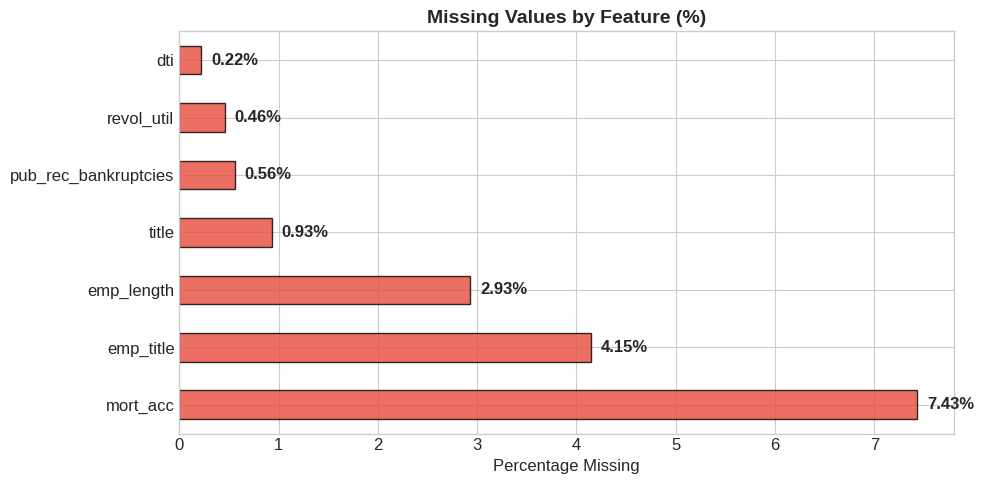

In [6]:
# Missing Values Analysis
print('='*80)
print('MISSING VALUES ANALYSIS')
print('='*80)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) > 0:
    print(missing_df)
    print(f'\n\u26a0\ufe0f Total features with missing values: {len(missing_df)}')
    print(f'\u26a0\ufe0f Total missing cells: {df.isnull().sum().sum()} ({df.isnull().sum().sum()/(df.shape[0]*df.shape[1])*100:.2f}%)')
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 5))
    missing_df['Missing %'].plot(kind='barh', color='#e74c3c', edgecolor='black', alpha=0.8, ax=ax)
    ax.set_title('Missing Values by Feature (%)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Percentage Missing')
    for i, v in enumerate(missing_df['Missing %']):
        ax.text(v + 0.1, i, f'{v}%', va='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figures/eda/missing_values.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('\u2705 No missing values found!')

In [7]:
# Duplicate Values Check
print('='*80)
print('DUPLICATE VALUES CHECK')
print('='*80)

duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

if duplicates > 0:
    print(f'Dropping {duplicates} duplicate rows...')
    df = df.drop_duplicates()
    print(f'New shape: {df.shape}')
else:
    print('\u2705 No duplicate rows found!')

DUPLICATE VALUES CHECK
Number of duplicate rows: 0
✅ No duplicate rows found!


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Analysis

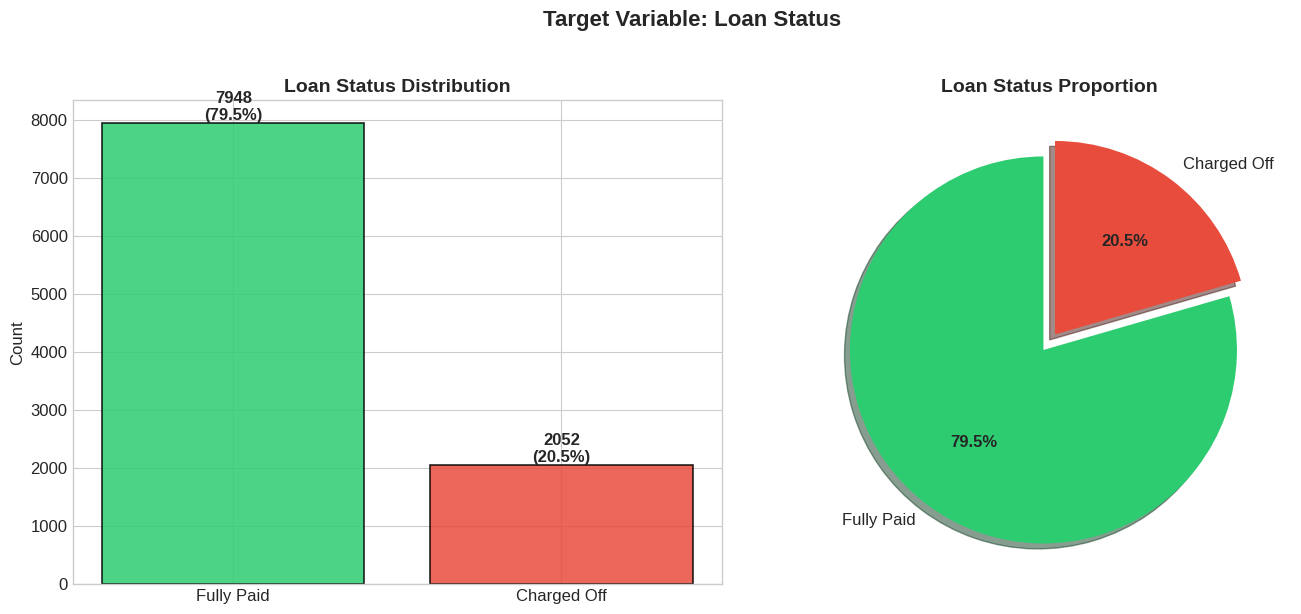


✅ ANSWER Q1: 79.48% of customers have Fully Paid their Loan Amount.
⚠️ The dataset is IMBALANCED - 20.52% defaults vs 79.48% fully paid.
⚠️ This asymmetry needs to be handled carefully during modeling.


In [8]:
# ============================================================
# TARGET VARIABLE DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count Plot
status_counts = df['loan_status'].value_counts()
ax1 = axes[0]
bars = ax1.bar(status_counts.index, status_counts.values, 
               color=[COLORS[s] for s in status_counts.index],
               edgecolor='black', linewidth=1.2, alpha=0.85)
for bar, val in zip(bars, status_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=12)
ax1.set_title('Loan Status Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count')

# Pie Chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(status_counts.values, 
                                    labels=status_counts.index,
                                    colors=[COLORS[s] for s in status_counts.index],
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    explode=(0.05, 0.05),
                                    shadow=True,
                                    textprops={'fontsize': 12})
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax2.set_title('Loan Status Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Loan Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

fully_paid_pct = (df['loan_status'] == 'Fully Paid').sum() / len(df) * 100
print(f'\n\u2705 ANSWER Q1: {fully_paid_pct:.2f}% of customers have Fully Paid their Loan Amount.')
print(f'\u26a0\ufe0f The dataset is IMBALANCED - {100-fully_paid_pct:.2f}% defaults vs {fully_paid_pct:.2f}% fully paid.')
print(f'\u26a0\ufe0f This asymmetry needs to be handled carefully during modeling.')

### 3.2 Univariate Analysis - Continuous Variables

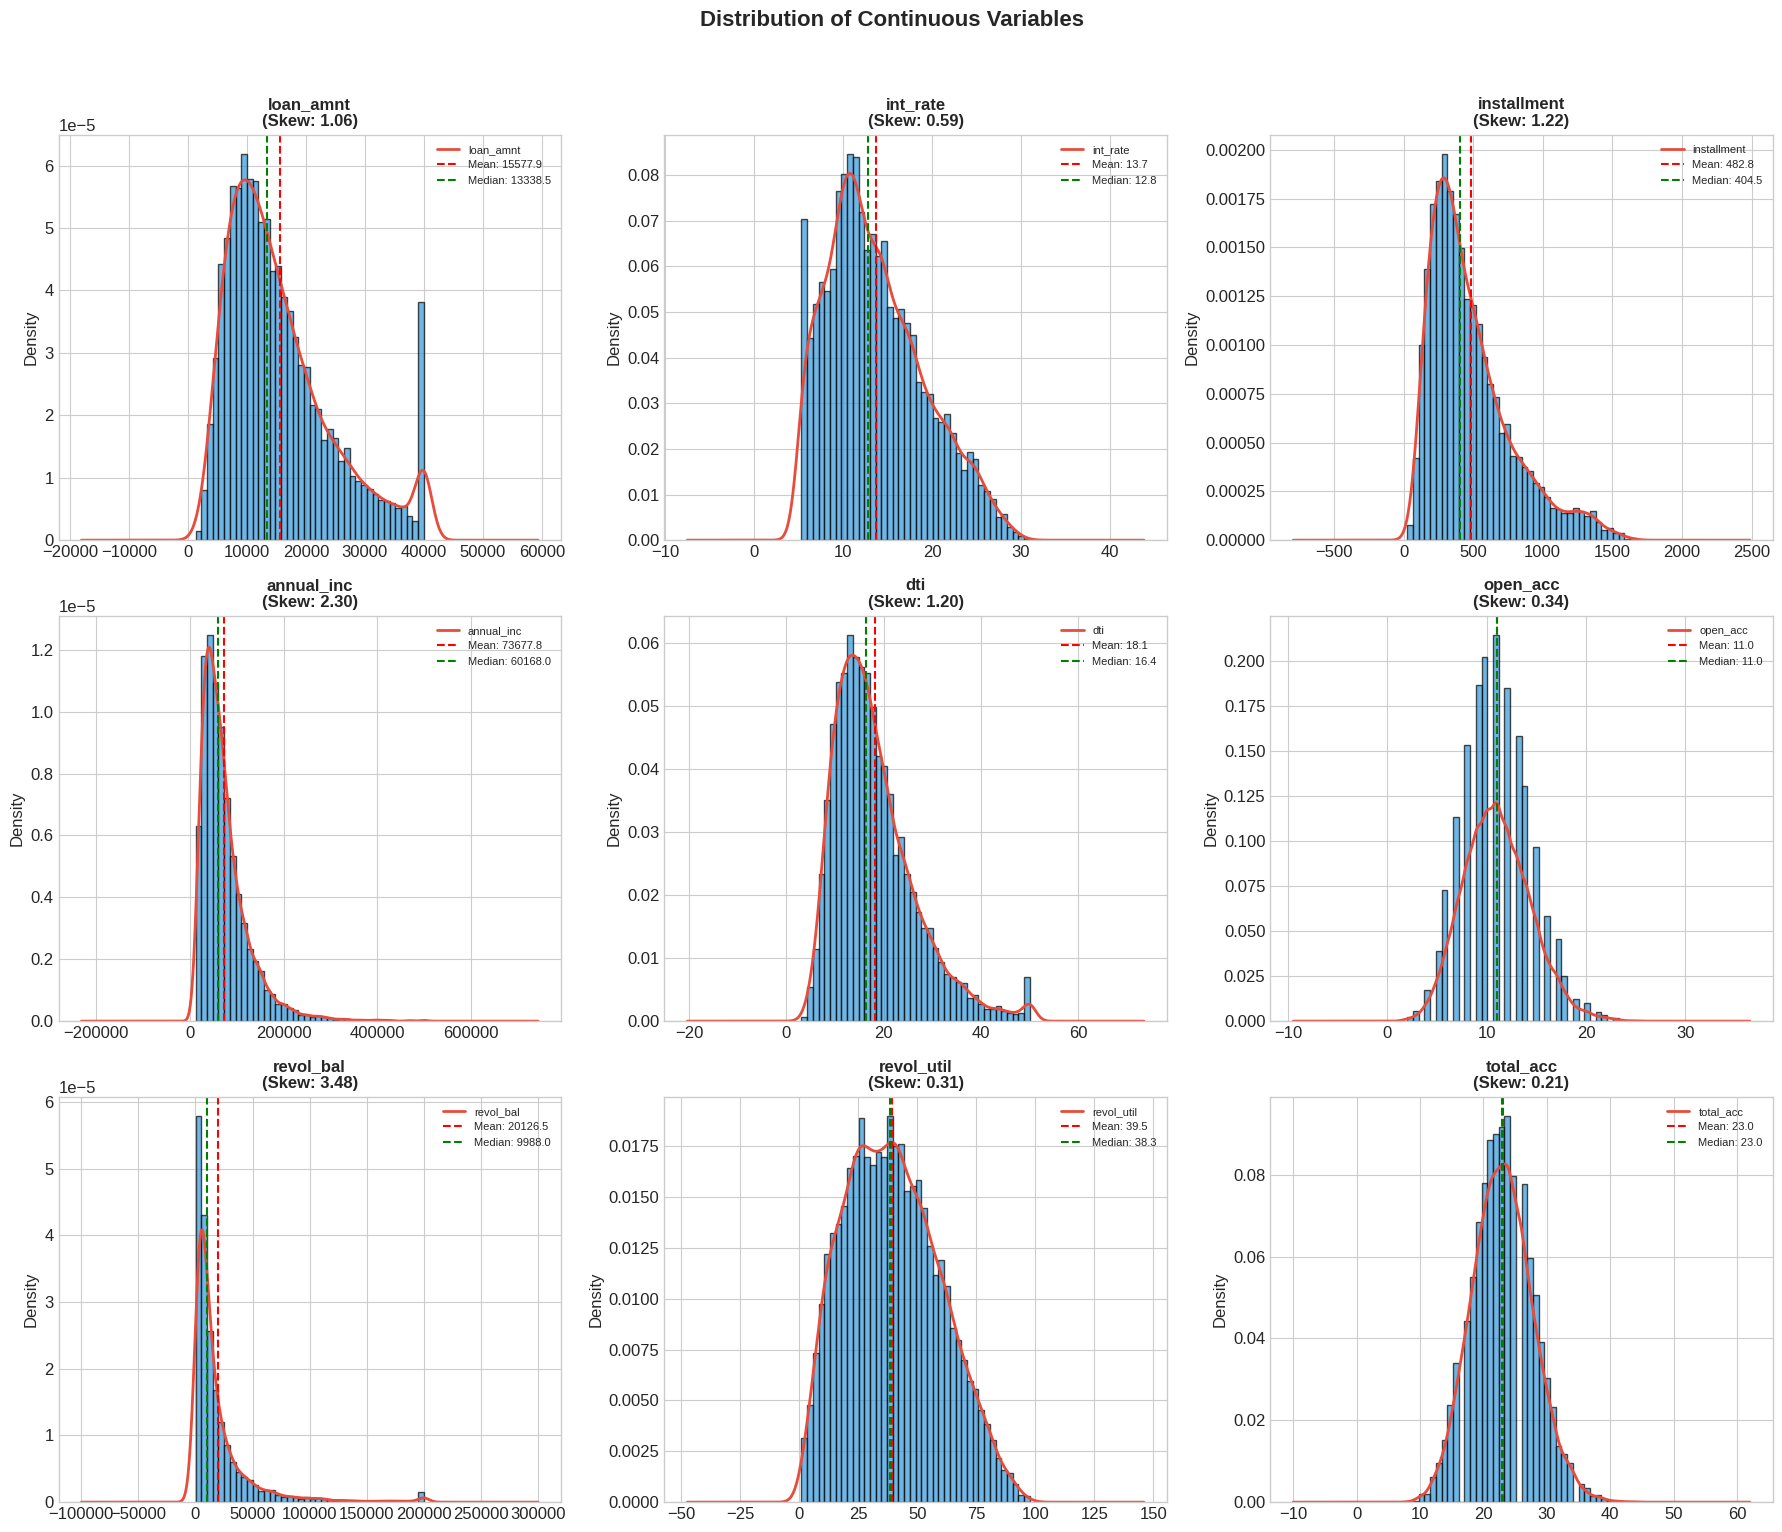

Exception in callback BaseAsyncIOLoop._handle_events(31, 1)
handle: <Handle BaseAsyncIOLoop._handle_events(31, 1)>
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "/home/ubuntu/.local/lib/python

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_c

In [9]:
# ============================================================
# DISTRIBUTION OF CONTINUOUS VARIABLES
# ============================================================
continuous_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 
                   'open_acc', 'revol_bal', 'revol_util', 'total_acc']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, col in enumerate(continuous_cols):
    ax = axes[idx]
    data = df[col].dropna()
    
    # Histogram with KDE
    ax.hist(data, bins=40, color='#3498db', alpha=0.7, edgecolor='black', density=True)
    data.plot(kind='kde', ax=ax, color='#e74c3c', linewidth=2)
    
    # Statistics
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}')
    
    skew = data.skew()
    ax.set_title(f'{col}\n(Skew: {skew:.2f})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Continuous Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/continuous_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n\ud83d\udcca OBSERVATIONS ON DISTRIBUTIONS:')
print('\u2022 loan_amnt: Right-skewed distribution, most loans are in the lower range')
print('\u2022 int_rate: Approximately normal distribution centered around 12-14%')
print('\u2022 annual_inc: Heavily right-skewed with some high-income outliers')
print('\u2022 dti: Right-skewed, most borrowers have moderate DTI ratios')
print('\u2022 revol_bal: Extremely right-skewed with significant outliers')

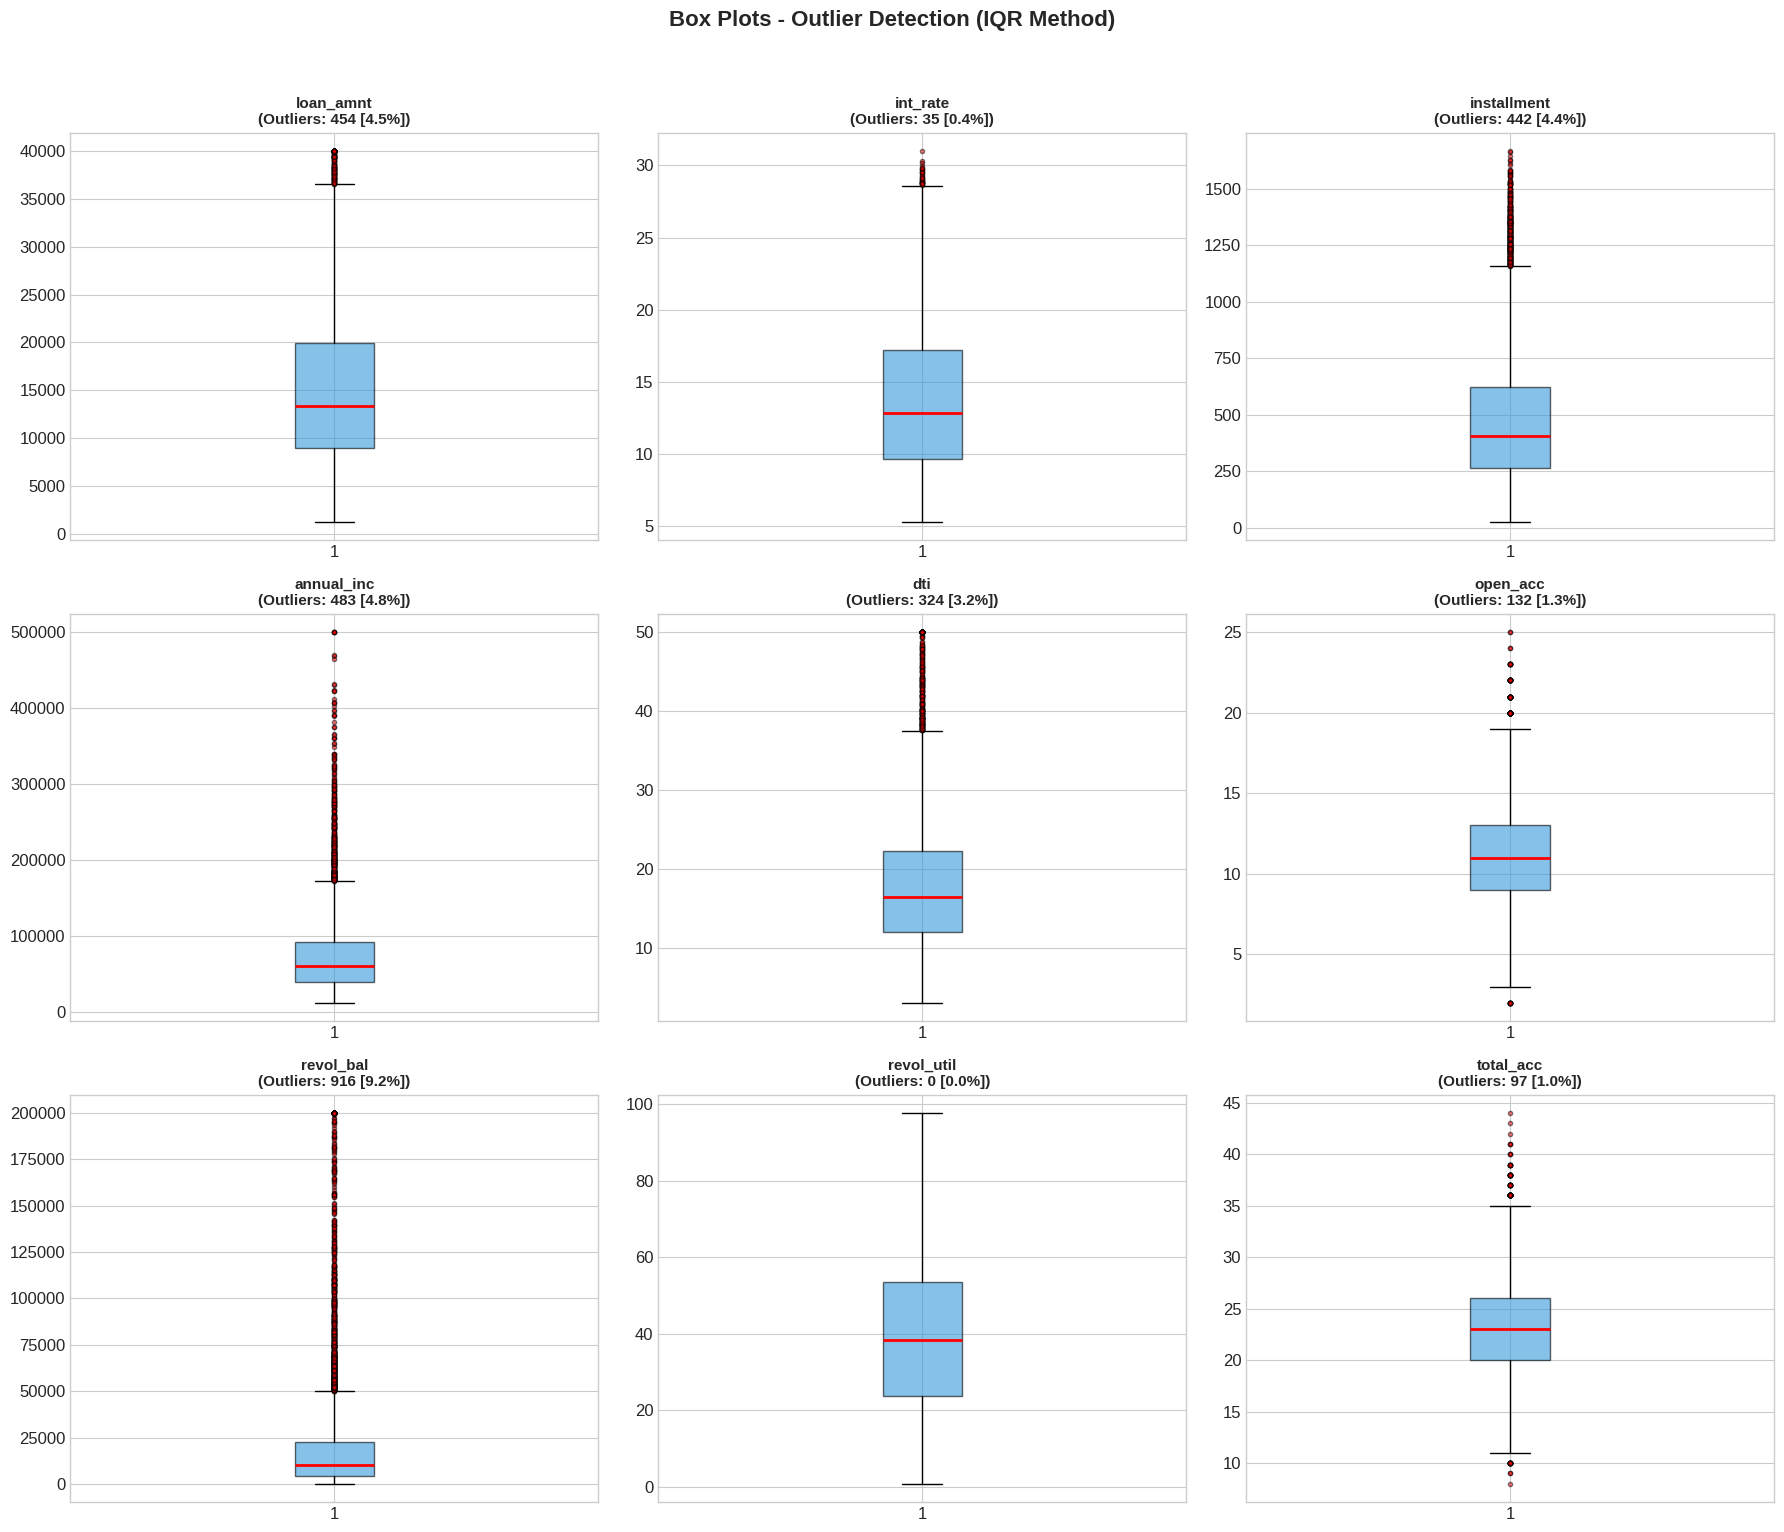

Exception in callback BaseAsyncIOLoop._handle_events(31, 1)
handle: <Handle BaseAsyncIOLoop._handle_events(31, 1)>
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "/home/ubuntu/.local/lib/python

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_c

In [10]:
# Box Plots for Outlier Detection
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, col in enumerate(continuous_cols):
    ax = axes[idx]
    data = df[col].dropna()
    
    bp = ax.boxplot(data, patch_artist=True, vert=True,
                     boxprops=dict(facecolor='#3498db', alpha=0.6),
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5))
    
    # Count outliers (IQR method)
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    
    ax.set_title(f'{col}\n(Outliers: {outliers} [{outliers/len(data)*100:.1f}%])', 
                  fontsize=11, fontweight='bold')

plt.suptitle('Box Plots - Outlier Detection (IQR Method)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/boxplots_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n\ud83d\udcca OBSERVATIONS ON OUTLIERS:')
print('\u2022 annual_inc has significant outliers on the upper end')
print('\u2022 revol_bal shows extreme outliers')
print('\u2022 loan_amnt and installment have moderate upper outliers')
print('\u2022 These outliers need treatment before model building')

### 3.3 Univariate Analysis - Categorical Variables

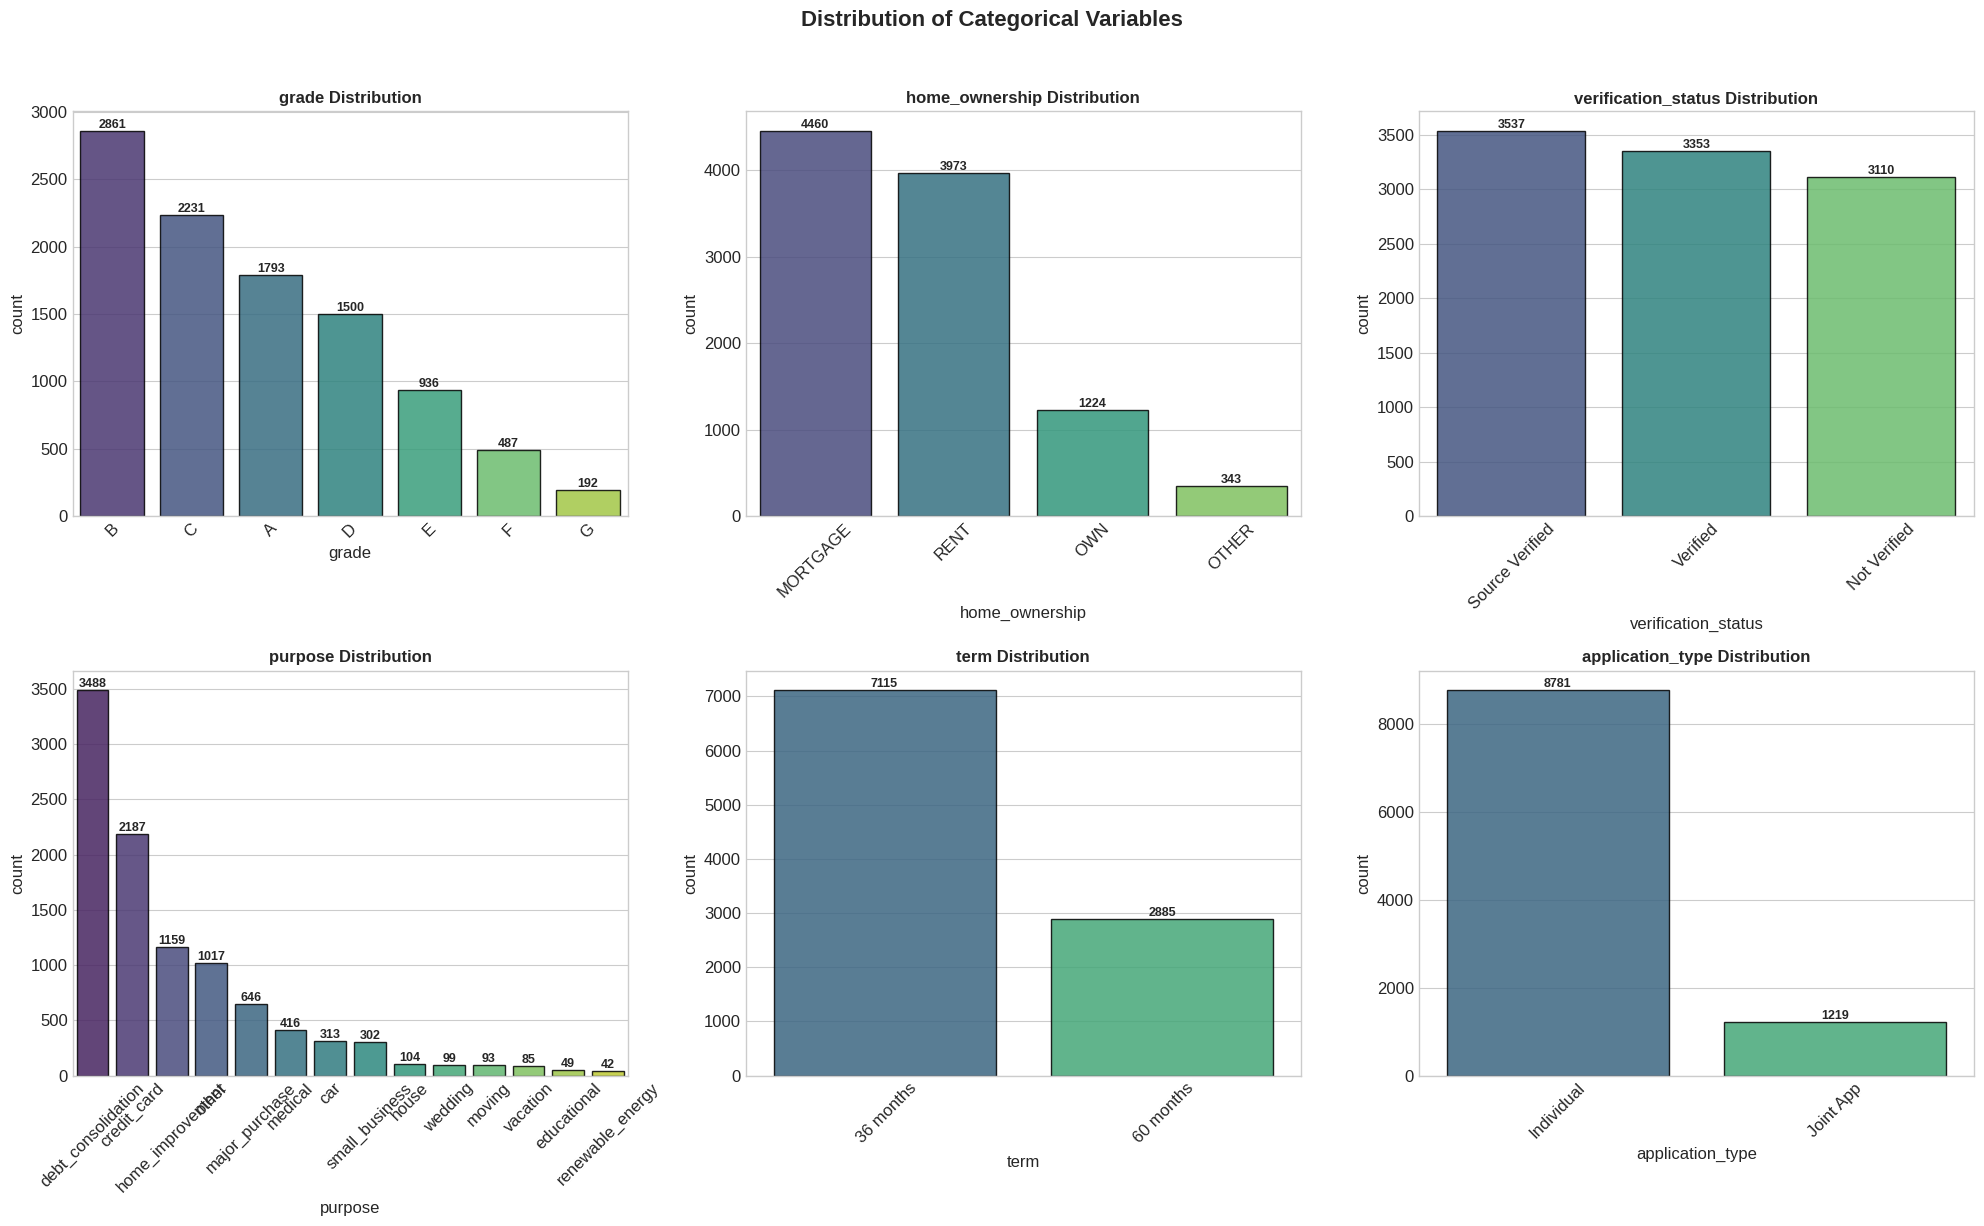

Exception in callback BaseAsyncIOLoop._handle_events(31, 1)
handle: <Handle BaseAsyncIOLoop._handle_events(31, 1)>
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 106-107: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "/home/ubuntu/.local/lib/pyth

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 106-107: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter

In [11]:
# ============================================================
# CATEGORICAL VARIABLES DISTRIBUTION
# ============================================================
cat_cols = ['grade', 'home_ownership', 'verification_status', 'purpose', 'term', 'application_type']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    ax = axes[idx]
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=ax, order=order, 
                  palette='viridis', edgecolor='black', alpha=0.85)
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    
    # Add count labels
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Distribution of Categorical Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

majority_home = df['home_ownership'].value_counts().index[0]
print(f'\n\u2705 ANSWER Q3: The majority of people have home ownership as \"{majority_home}\".')
print(f'\n\ud83d\udcca OBSERVATIONS:')
print(f'\u2022 Grade B is the most common loan grade')
print(f'\u2022 Most loans are for 36 months term')
print(f'\u2022 Individual applications dominate over joint applications')
print(f'\u2022 Debt consolidation is the top purpose for loans')

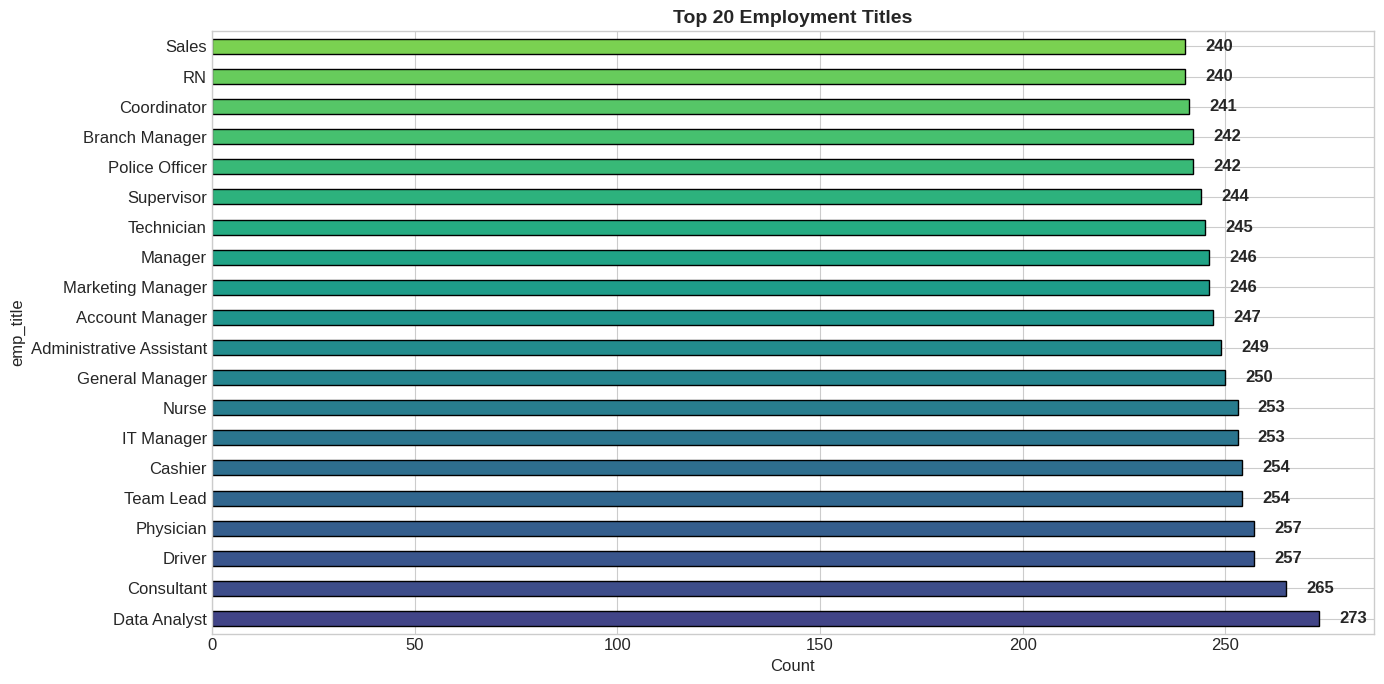


✅ ANSWER Q5: The top 2 afforded job titles are:
   1. Data Analyst (273 borrowers)
   2. Consultant (265 borrowers)


In [12]:
# Employment Title Analysis - Top 20
fig, ax = plt.subplots(figsize=(14, 7))
top_titles = df['emp_title'].value_counts().head(20)
top_titles.plot(kind='barh', color=plt.cm.viridis(np.linspace(0.2, 0.8, 20)), 
                edgecolor='black', ax=ax)
ax.set_title('Top 20 Employment Titles', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
for i, v in enumerate(top_titles.values):
    ax.text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/eda/top_employment_titles.png', dpi=300, bbox_inches='tight')
plt.show()

top2 = df['emp_title'].value_counts().head(2)
print(f'\n\u2705 ANSWER Q5: The top 2 afforded job titles are:')
print(f'   1. {top2.index[0]} ({top2.values[0]} borrowers)')
print(f'   2. {top2.index[1]} ({top2.values[1]} borrowers)')

### 3.4 Bivariate Analysis - Target vs Features

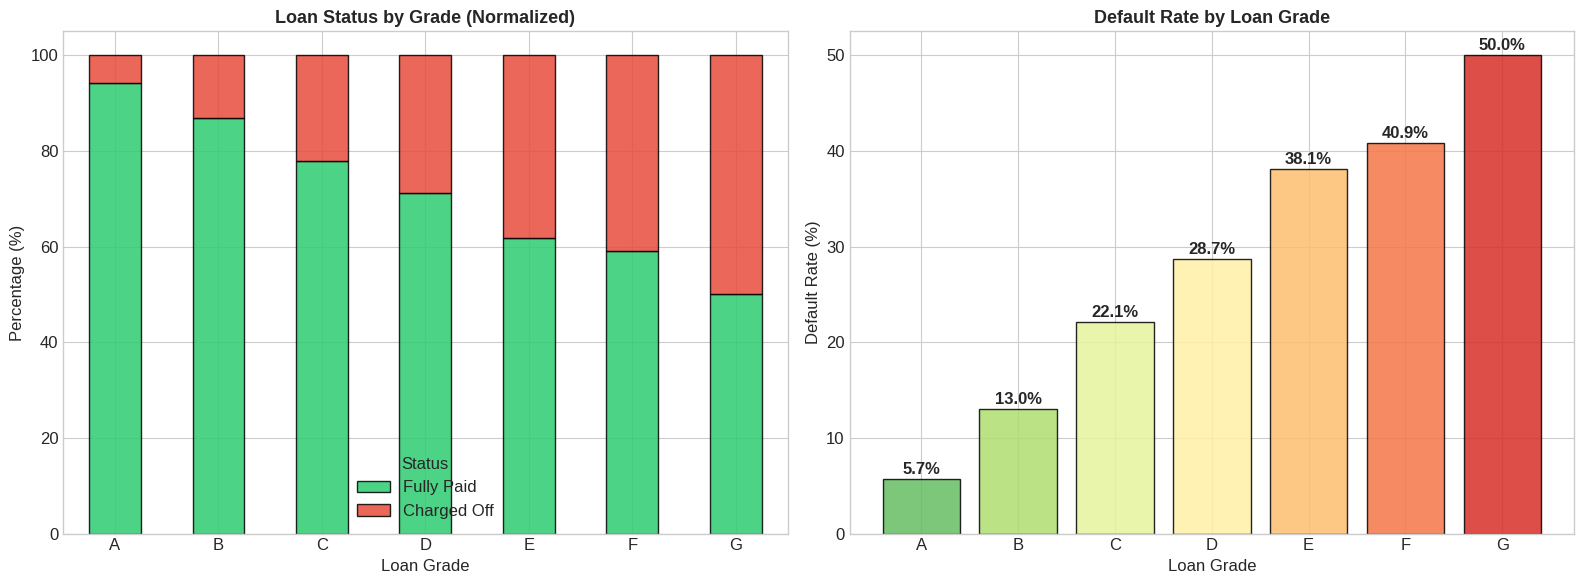

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 196-197: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter

ERROR:tornado.general:Uncaught exception in zmqstream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 196-197: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.

In [13]:
# ============================================================
# LOAN STATUS BY GRADE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar chart
grade_status = pd.crosstab(df['grade'], df['loan_status'], normalize='index') * 100
grade_status[['Fully Paid', 'Charged Off']].plot(kind='bar', stacked=True, 
    color=PALETTE, edgecolor='black', ax=axes[0], alpha=0.85)
axes[0].set_title('Loan Status by Grade (Normalized)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('Loan Grade')
axes[0].legend(title='Status')
axes[0].tick_params(axis='x', rotation=0)

# Default rate by grade
default_rate = df.groupby('grade')['loan_status'].apply(lambda x: (x == 'Charged Off').mean() * 100)
bars = axes[1].bar(default_rate.index, default_rate.values, 
                    color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(default_rate))),
                    edgecolor='black', alpha=0.85)
for bar, val in zip(bars, default_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Default Rate by Loan Grade', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xlabel('Loan Grade')

plt.tight_layout()
plt.savefig('../figures/eda/grade_vs_status.png', dpi=300, bbox_inches='tight')
plt.show()

grade_a_paid = (df[df['grade']=='A']['loan_status'] == 'Fully Paid').mean() * 100
print(f'\n\u2705 ANSWER Q4: People with grade A have {grade_a_paid:.1f}% full payment rate.')
print(f'   Grade A has the LOWEST default rate \u2192 TRUE - People with grades A are more likely to fully pay.')
print(f'\n\ud83d\udcca INSIGHT: There is a clear monotonic relationship between grade and default rate.')
print(f'   Grade A: ~{default_rate["A"]:.1f}% default vs Grade G: ~{default_rate["G"]:.1f}% default')

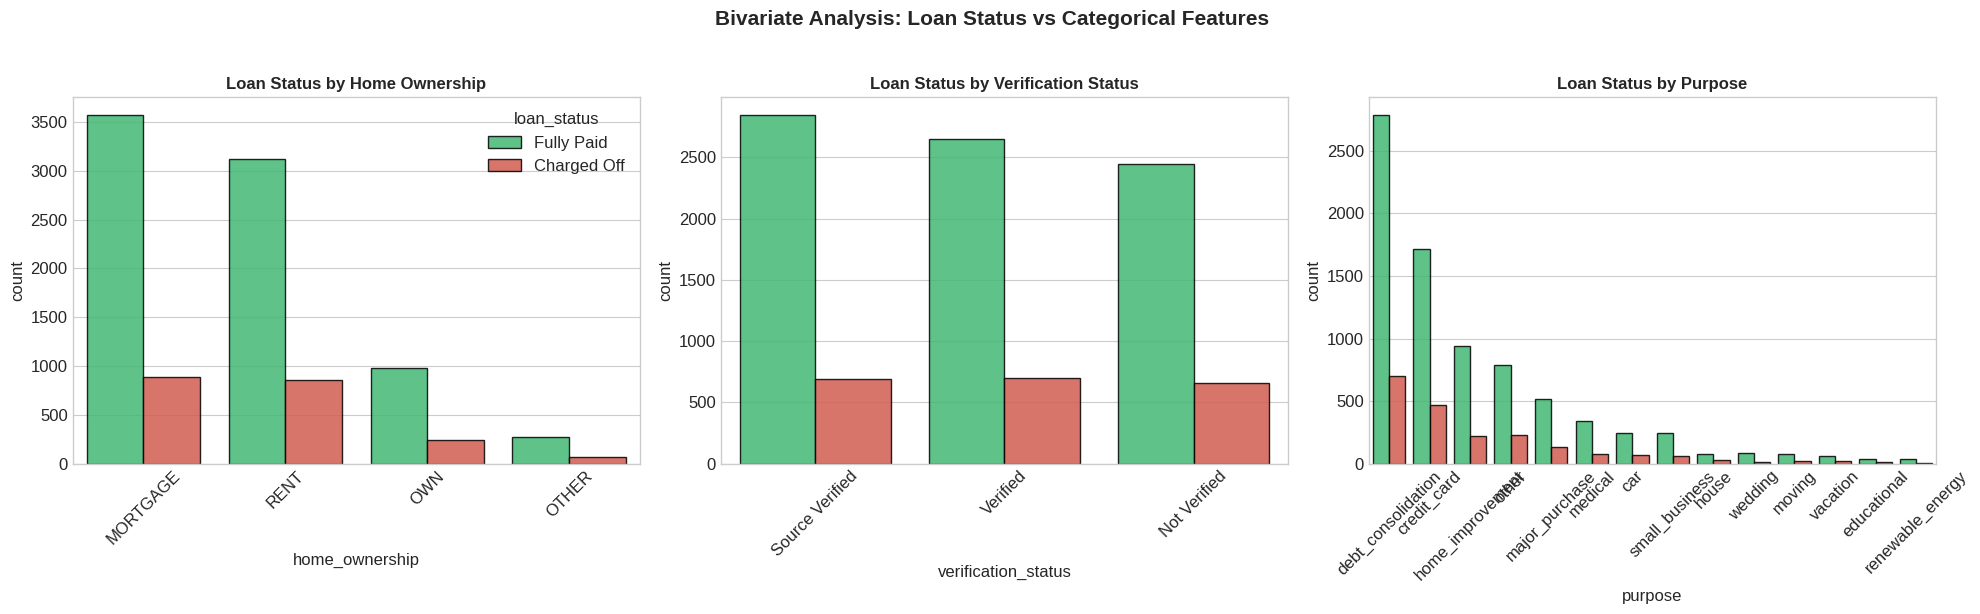

In [14]:
# ============================================================
# LOAN STATUS BY HOME OWNERSHIP, PURPOSE, VERIFICATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, col in enumerate(['home_ownership', 'verification_status', 'purpose']):
    ax = axes[idx]
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue='loan_status', ax=ax, order=order,
                  palette=COLORS, edgecolor='black', alpha=0.85)
    ax.set_title(f'Loan Status by {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    if idx > 0:
        ax.get_legend().remove()

plt.suptitle('Bivariate Analysis: Loan Status vs Categorical Features', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/bivariate_categorical.png', dpi=300, bbox_inches='tight')
plt.show()

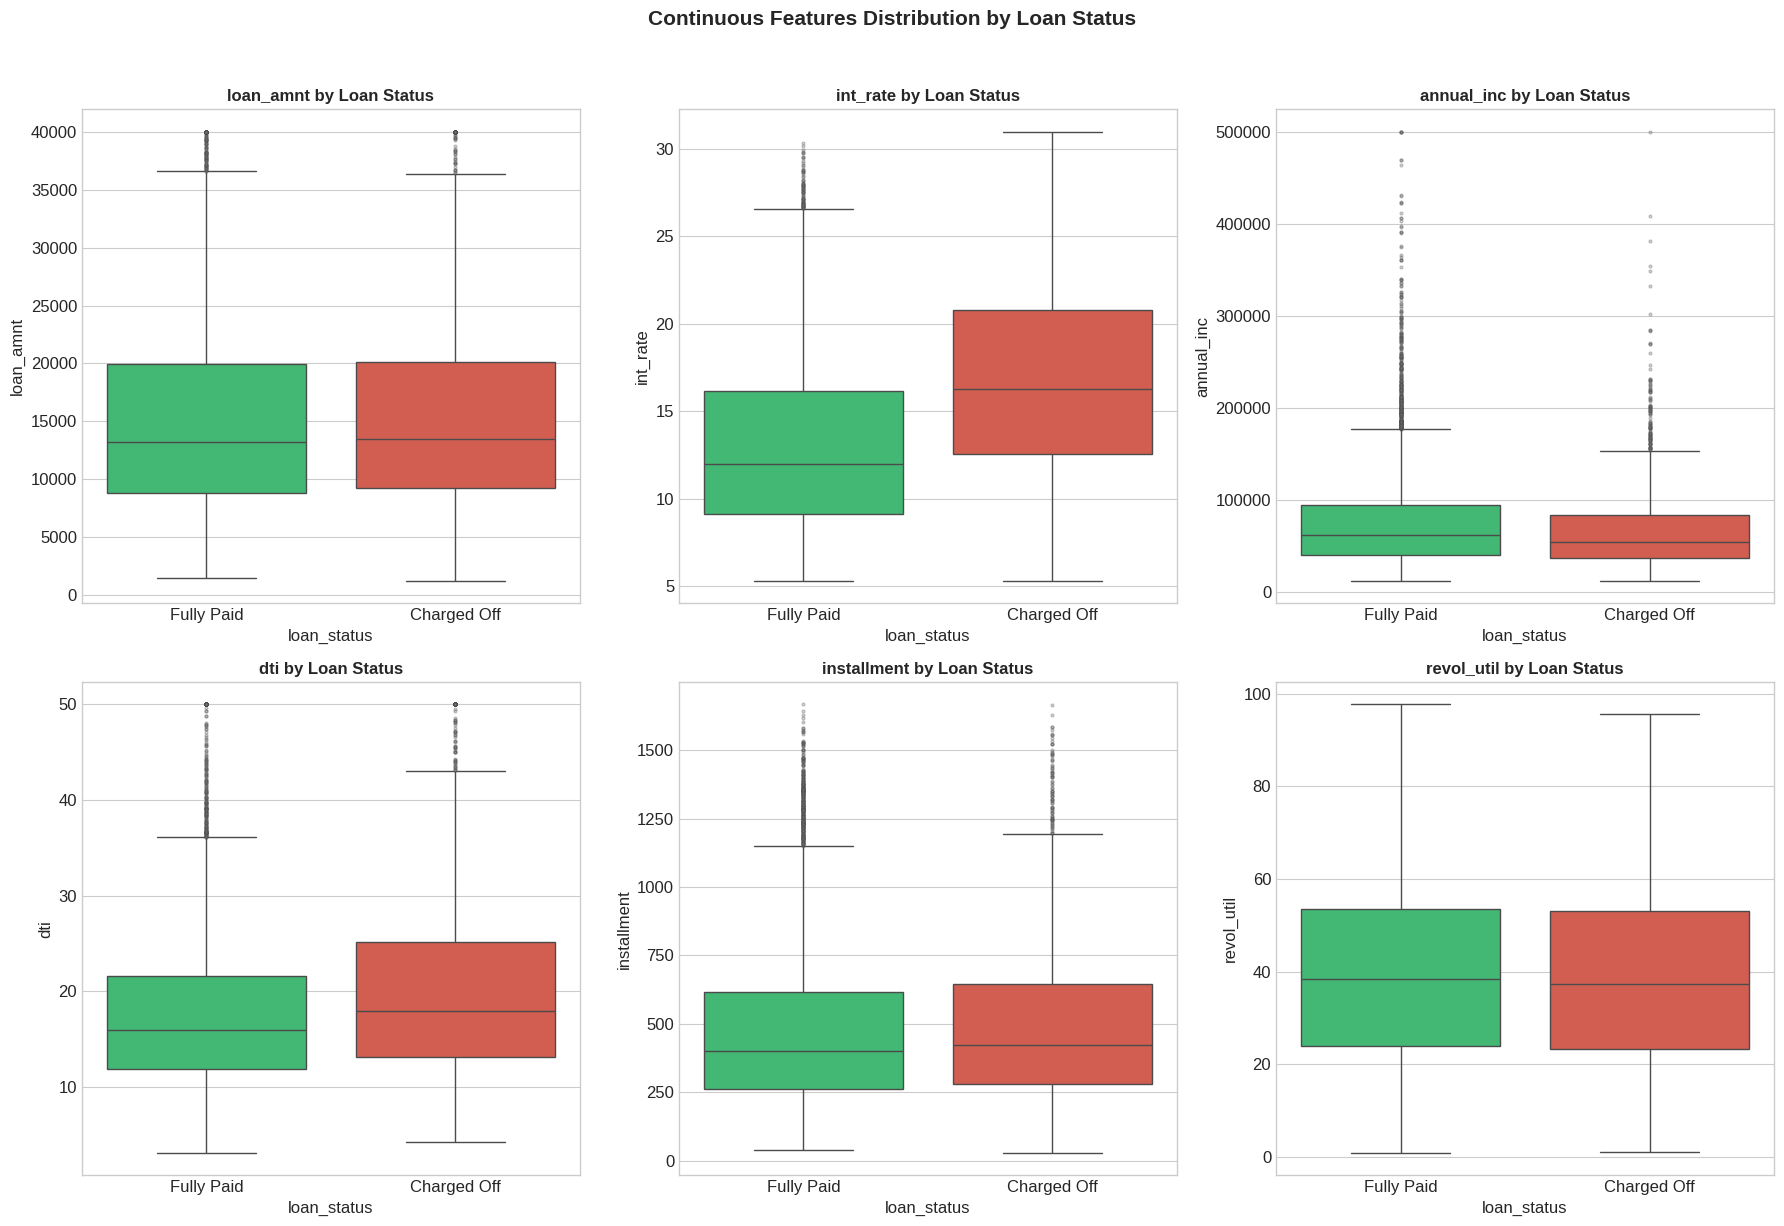

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_c

In [15]:
# ============================================================
# BOX PLOTS: CONTINUOUS FEATURES BY LOAN STATUS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

bivar_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'installment', 'revol_util']

for idx, col in enumerate(bivar_cols):
    ax = axes[idx]
    sns.boxplot(data=df, x='loan_status', y=col, ax=ax, palette=COLORS,
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=2, alpha=0.3))
    ax.set_title(f'{col} by Loan Status', fontsize=12, fontweight='bold')

plt.suptitle('Continuous Features Distribution by Loan Status', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/bivariate_continuous.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n\ud83d\udcca BIVARIATE INSIGHTS:')
print('\u2022 Charged Off loans tend to have higher interest rates')
print('\u2022 Higher loan amounts are slightly more likely to default')
print('\u2022 Annual income distributions overlap significantly between groups')
print('\u2022 DTI ratio is slightly higher for defaulters')

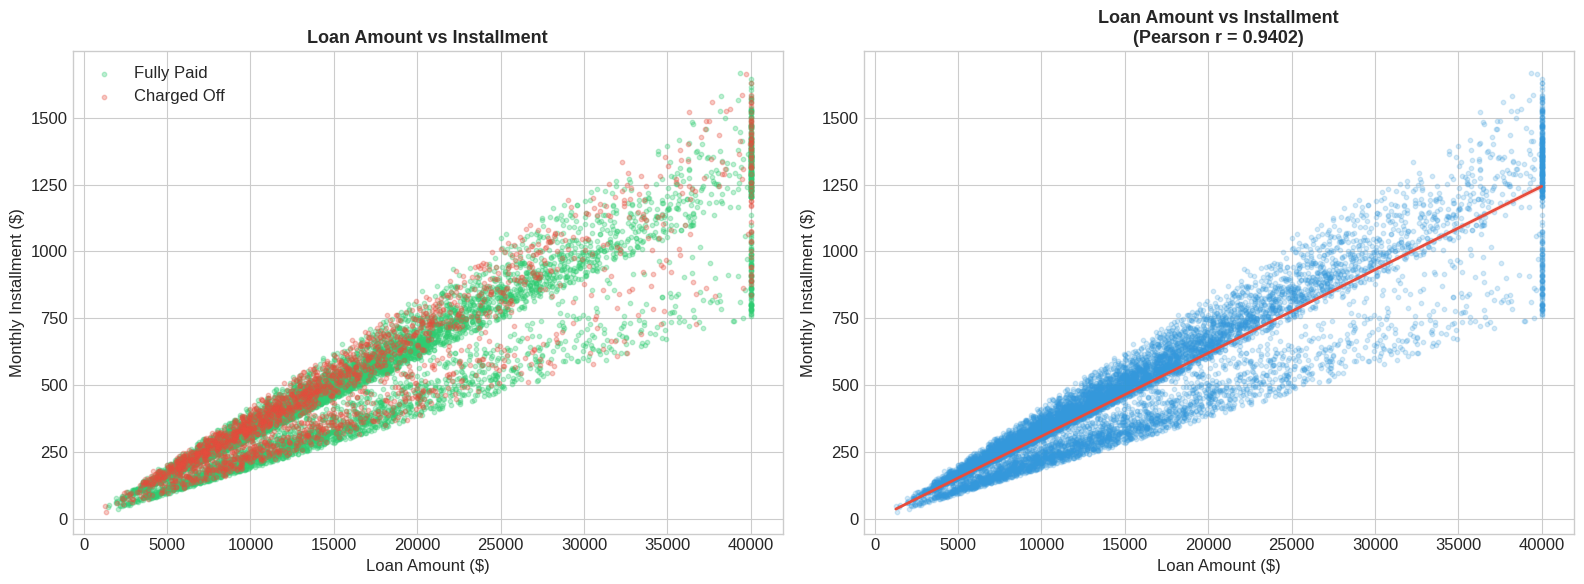


✅ ANSWER Q2: The correlation between Loan Amount and Installment is 0.9402.
   This is a VERY STRONG POSITIVE correlation, which makes intuitive sense as
   higher loan amounts naturally lead to higher monthly installments.
   ⚠️ This high collinearity means we should consider dropping one feature.


In [16]:
# ============================================================
# LOAN AMOUNT VS INSTALLMENT CORRELATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
ax1 = axes[0]
for status in ['Fully Paid', 'Charged Off']:
    mask = df['loan_status'] == status
    ax1.scatter(df.loc[mask, 'loan_amnt'], df.loc[mask, 'installment'],
                alpha=0.3, s=10, label=status, color=COLORS[status])
ax1.set_title('Loan Amount vs Installment', fontsize=13, fontweight='bold')
ax1.set_xlabel('Loan Amount ($)')
ax1.set_ylabel('Monthly Installment ($)')
ax1.legend()

# Regression plot
ax2 = axes[1]
sns.regplot(data=df, x='loan_amnt', y='installment', ax=ax2, 
            scatter_kws={'alpha': 0.2, 's': 10, 'color': '#3498db'},
            line_kws={'color': '#e74c3c', 'linewidth': 2})
corr_val = df['loan_amnt'].corr(df['installment'])
ax2.set_title(f'Loan Amount vs Installment\n(Pearson r = {corr_val:.4f})', fontsize=13, fontweight='bold')
ax2.set_xlabel('Loan Amount ($)')
ax2.set_ylabel('Monthly Installment ($)')

plt.tight_layout()
plt.savefig('../figures/eda/loan_amnt_vs_installment.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n\u2705 ANSWER Q2: The correlation between Loan Amount and Installment is {corr_val:.4f}.')
print(f'   This is a VERY STRONG POSITIVE correlation, which makes intuitive sense as')
print(f'   higher loan amounts naturally lead to higher monthly installments.')
print(f'   \u26a0\ufe0f This high collinearity means we should consider dropping one feature.')

### 3.5 Correlation Analysis

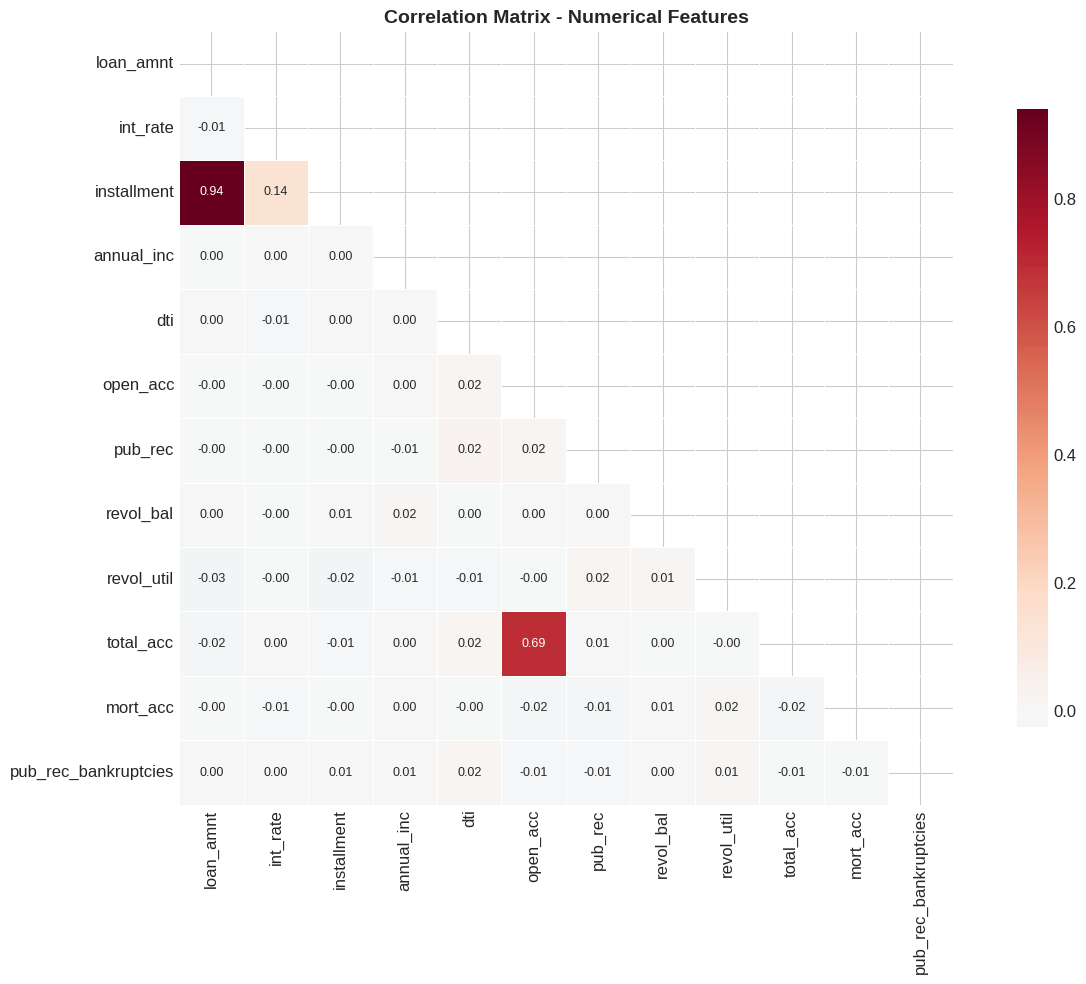

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_c

ERROR:tornado.general:Uncaught exception in zmqstream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.lo

In [17]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/eda/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n\ud83d\udcca CORRELATION INSIGHTS:')
# Find highly correlated pairs
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr:
    print('\nHighly Correlated Pairs (|r| > 0.5):')
    for c1, c2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f'  \u2022 {c1} <-> {c2}: r = {r:.3f}')

---

## 4. Data Preprocessing & Feature Engineering

### 4.1 Feature Engineering

In [18]:
# ============================================================
# CREATE A WORKING COPY
# ============================================================
df_model = df.copy()
print(f'Working dataset shape: {df_model.shape}')

# ============================================================
# FEATURE ENGINEERING
# ============================================================

# 1. Binary Target Encoding
df_model['target'] = (df_model['loan_status'] == 'Charged Off').astype(int)
print(f'\n\u2705 Target variable encoded: Charged Off = 1, Fully Paid = 0')
print(df_model['target'].value_counts())

# 2. Flag Features (as specified in requirements)
df_model['pub_rec_flag'] = (df_model['pub_rec'] > 0).astype(int)
df_model['mort_acc_flag'] = (df_model['mort_acc'] > 0).astype(int)
df_model['pub_rec_bankruptcies_flag'] = (df_model['pub_rec_bankruptcies'] > 0).astype(int)

print(f'\n\u2705 Flag features created:')
print(f'   pub_rec_flag: {df_model["pub_rec_flag"].value_counts().to_dict()}')
print(f'   mort_acc_flag: {df_model["mort_acc_flag"].value_counts().to_dict()}')
print(f'   pub_rec_bankruptcies_flag: {df_model["pub_rec_bankruptcies_flag"].value_counts().to_dict()}')

# 3. Term encoding
df_model['term_numeric'] = df_model['term'].str.strip().str.split().str[0].astype(int)
print(f'\n\u2705 Term encoded to numeric: {df_model["term_numeric"].unique()}')

# 4. Employment length encoding
emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10
}
df_model['emp_length_numeric'] = df_model['emp_length'].map(emp_length_map)
print(f'\u2705 Employment length encoded to numeric')

# 5. Extract state from address
df_model['state'] = df_model['address'].str.extract(r'([A-Z]{2})\s+\d{5}$')
print(f'\u2705 State extracted from address: {df_model["state"].nunique()} unique states')

# 6. Credit history length (months)
df_model['issue_date'] = pd.to_datetime(df_model['issue_d'], format='%b-%Y')
df_model['earliest_cr_date'] = pd.to_datetime(df_model['earliest_cr_line'], format='%b-%Y')
df_model['credit_history_months'] = ((df_model['issue_date'] - df_model['earliest_cr_date']).dt.days / 30).astype(int)
print(f'\u2705 Credit history length calculated (months)')

# 7. Income to loan ratio
df_model['income_to_loan_ratio'] = df_model['annual_inc'] / (df_model['loan_amnt'] + 1)
print(f'\u2705 Income to loan ratio calculated')

# 8. Installment to income ratio
df_model['installment_to_income'] = df_model['installment'] / (df_model['annual_inc'] / 12 + 1)
print(f'\u2705 Installment to income ratio calculated')

print(f'\n\ud83d\udcca New dataset shape after feature engineering: {df_model.shape}')

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 588-589: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter

ERROR:tornado.general:Uncaught exception in zmqstream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 588-589: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.

### 4.2 Missing Value Treatment

In [19]:
# ============================================================
# MISSING VALUE TREATMENT
# ============================================================
print('Missing values BEFORE treatment:')
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

# emp_length_numeric: Fill with median
df_model['emp_length_numeric'].fillna(df_model['emp_length_numeric'].median(), inplace=True)

# mort_acc: Fill with median by total_acc group (correlated)
mort_acc_by_total = df_model.groupby('total_acc')['mort_acc'].median()
def fill_mort_acc(row):
    if pd.isna(row['mort_acc']):
        return mort_acc_by_total.get(row['total_acc'], df_model['mort_acc'].median())
    return row['mort_acc']
df_model['mort_acc'] = df_model.apply(fill_mort_acc, axis=1)

# mort_acc_flag: recalculate after filling
df_model['mort_acc_flag'] = (df_model['mort_acc'] > 0).astype(int)

# revol_util: Fill with median
df_model['revol_util'].fillna(df_model['revol_util'].median(), inplace=True)

# pub_rec_bankruptcies: Fill with 0 (mode)
df_model['pub_rec_bankruptcies'].fillna(0, inplace=True)
df_model['pub_rec_bankruptcies_flag'] = (df_model['pub_rec_bankruptcies'] > 0).astype(int)

# dti: Fill with median
df_model['dti'].fillna(df_model['dti'].median(), inplace=True)

print(f'\n\u2705 Missing values AFTER treatment:')
remaining_missing = df_model.isnull().sum()[df_model.isnull().sum() > 0]
if len(remaining_missing) > 0:
    print(remaining_missing)
else:
    print('No missing values in model features!')

Missing values BEFORE treatment:
emp_title               415
emp_length              293
title                    93
dti                      22
revol_util               46
mort_acc                743
pub_rec_bankruptcies     56
emp_length_numeric      293
dtype: int64



✅ Missing values AFTER treatment:
emp_title               415
emp_length              293
title                    93
dti                      22
revol_util               46
pub_rec_bankruptcies     56
emp_length_numeric      293
dtype: int64


### 4.3 Outlier Treatment

In [20]:
# ============================================================
# OUTLIER TREATMENT (Winsorization / Capping)
# ============================================================
def cap_outliers(df, col, lower_pct=0.01, upper_pct=0.99):
    """Cap outliers at specified percentiles."""
    lower = df[col].quantile(lower_pct)
    upper = df[col].quantile(upper_pct)
    original_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    return original_outliers

outlier_cols = ['annual_inc', 'revol_bal', 'dti', 'open_acc', 'total_acc']

print('OUTLIER TREATMENT (Winsorization at 1st and 99th percentile):')
print('='*60)
for col in outlier_cols:
    n_outliers = cap_outliers(df_model, col)
    print(f'  {col}: {n_outliers} outliers capped')

print('\n\u2705 Outlier treatment completed!')

OUTLIER TREATMENT (Winsorization at 1st and 99th percentile):
  annual_inc: 200 outliers capped
  revol_bal: 200 outliers capped


  dti: 198 outliers capped
  open_acc: 106 outliers capped
  total_acc: 170 outliers capped

✅ Outlier treatment completed!


### 4.4 Data Preparation for Modeling

In [21]:
# ============================================================
# SELECT FEATURES FOR MODELING
# ============================================================

# Drop columns not useful for modeling
cols_to_drop = ['loan_status', 'emp_title', 'emp_length', 'title', 'issue_d', 
                'earliest_cr_line', 'address', 'sub_grade', 'term',
                'issue_date', 'earliest_cr_date', 'state', 'installment']

df_features = df_model.drop(columns=cols_to_drop, errors='ignore')

print(f'Features selected: {df_features.shape[1]-1} features')
print(f'\nNumerical features:')
num_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('target')
print(f'  {num_cols}')

cat_cols_model = df_features.select_dtypes(include=['object']).columns.tolist()
print(f'\nCategorical features to encode:')
print(f'  {cat_cols_model}')

Features selected: 25 features

Numerical features:
  ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'pub_rec_flag', 'mort_acc_flag', 'pub_rec_bankruptcies_flag', 'term_numeric', 'emp_length_numeric', 'credit_history_months', 'income_to_loan_ratio', 'installment_to_income']

Categorical features to encode:
  ['grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type']


In [22]:
# ============================================================
# ENCODE CATEGORICAL VARIABLES
# ============================================================

# Grade: Ordinal encoding
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_features['grade'] = df_features['grade'].map(grade_map)

# One-hot encoding for remaining categorical features
cat_cols_remaining = [c for c in cat_cols_model if c != 'grade']
df_features = pd.get_dummies(df_features, columns=cat_cols_remaining, drop_first=True, dtype=int)

print(f'\u2705 Encoding complete. Final features shape: {df_features.shape}')
print(f'\nAll features ({df_features.shape[1]-1}):')
feature_names = [c for c in df_features.columns if c != 'target']
for i, f in enumerate(feature_names):
    print(f'  {i+1:2d}. {f}')

✅ Encoding complete. Final features shape: (10000, 41)

All features (40):
   1. loan_amnt
   2. int_rate
   3. grade
   4. annual_inc
   5. dti
   6. open_acc
   7. pub_rec
   8. revol_bal
   9. revol_util
  10. total_acc
  11. mort_acc
  12. pub_rec_bankruptcies
  13. pub_rec_flag
  14. mort_acc_flag
  15. pub_rec_bankruptcies_flag
  16. term_numeric
  17. emp_length_numeric
  18. credit_history_months
  19. income_to_loan_ratio
  20. installment_to_income
  21. home_ownership_OTHER
  22. home_ownership_OWN
  23. home_ownership_RENT
  24. verification_status_Source Verified
  25. verification_status_Verified
  26. purpose_credit_card
  27. purpose_debt_consolidation
  28. purpose_educational
  29. purpose_home_improvement
  30. purpose_house
  31. purpose_major_purchase
  32. purpose_medical
  33. purpose_moving
  34. purpose_other
  35. purpose_renewable_energy
  36. purpose_small_business
  37. purpose_vacation
  38. purpose_wedding
  39. initial_list_status_w
  40. application_typ

In [23]:
# ============================================================
# TRAIN-TEST SPLIT & SCALING
# ============================================================

X = df_features.drop('target', axis=1)
y = df_features['target']

# Final safety check: fill any remaining NaNs
remaining_nan = X.isnull().sum().sum()
if remaining_nan > 0:
    print(f'Filling {remaining_nan} remaining NaN values with column medians...')
    X = X.fillna(X.median())
    X = X.fillna(0)

print(f'Feature matrix shape: {X.shape}')
print(f'Target variable shape: {y.shape}')
print(f'Remaining NaN: {X.isnull().sum().sum()}')
print(f'Target distribution:\n{y.value_counts()}')

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'\n\u2705 Train-Test Split (75-25):')
print(f'  Training set: {X_train.shape[0]} samples')
print(f'  Test set:     {X_test.shape[0]} samples')
print(f'  Train target: {y_train.value_counts().to_dict()}')
print(f'  Test target:  {y_test.value_counts().to_dict()}')

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f'\n\u2705 StandardScaler applied successfully!')

Filling 417 remaining NaN values with column medians...
Feature matrix shape: (10000, 40)
Target variable shape: (10000,)
Remaining NaN: 0
Target distribution:
target
0    7948
1    2052
Name: count, dtype: int64

✅ Train-Test Split (75-25):
  Training set: 7500 samples
  Test set:     2500 samples
  Train target: {0: 5961, 1: 1539}
  Test target:  {0: 1987, 1: 513}

✅ StandardScaler applied successfully!


---

## 5. Model Building - Logistic Regression

### 5.1 Scikit-learn Logistic Regression

In [24]:
# ============================================================
# LOGISTIC REGRESSION MODEL (Scikit-learn)
# ============================================================

# Using class_weight='balanced' to handle class imbalance
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42,
    C=1.0
)

lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print('\u2705 Logistic Regression Model Trained Successfully!')
print(f'\nModel Parameters:')
print(f'  Solver: lbfgs')
print(f'  Regularization (C): 1.0')
print(f'  Class Weight: balanced')
print(f'  Max Iterations: 1000')
print(f'\nTraining Accuracy: {lr_model.score(X_train_scaled, y_train):.4f}')
print(f'Test Accuracy:     {lr_model.score(X_test_scaled, y_test):.4f}')

✅ Logistic Regression Model Trained Successfully!

Model Parameters:
  Solver: lbfgs
  Regularization (C): 1.0
  Class Weight: balanced
  Max Iterations: 1000

Training Accuracy: 0.6809
Test Accuracy:     0.6760


MODEL COEFFICIENTS (Sorted by Absolute Value)
                            Feature  Coefficient  Odds_Ratio
                              grade         0.70        2.01
                                dti         0.36        1.44
               income_to_loan_ratio        -0.16        0.85
                       term_numeric         0.15        1.16
                          loan_amnt        -0.09        0.91
                home_ownership_RENT         0.09        1.09
                           mort_acc         0.09        1.09
                         annual_inc        -0.08        0.92
                           int_rate         0.07        1.07
                      purpose_other         0.07        1.07
              installment_to_income         0.07        1.07
                            pub_rec         0.06        1.06
verification_status_Source Verified        -0.06        0.94
                purpose_credit_card         0.06        1.06
                           open_acc    

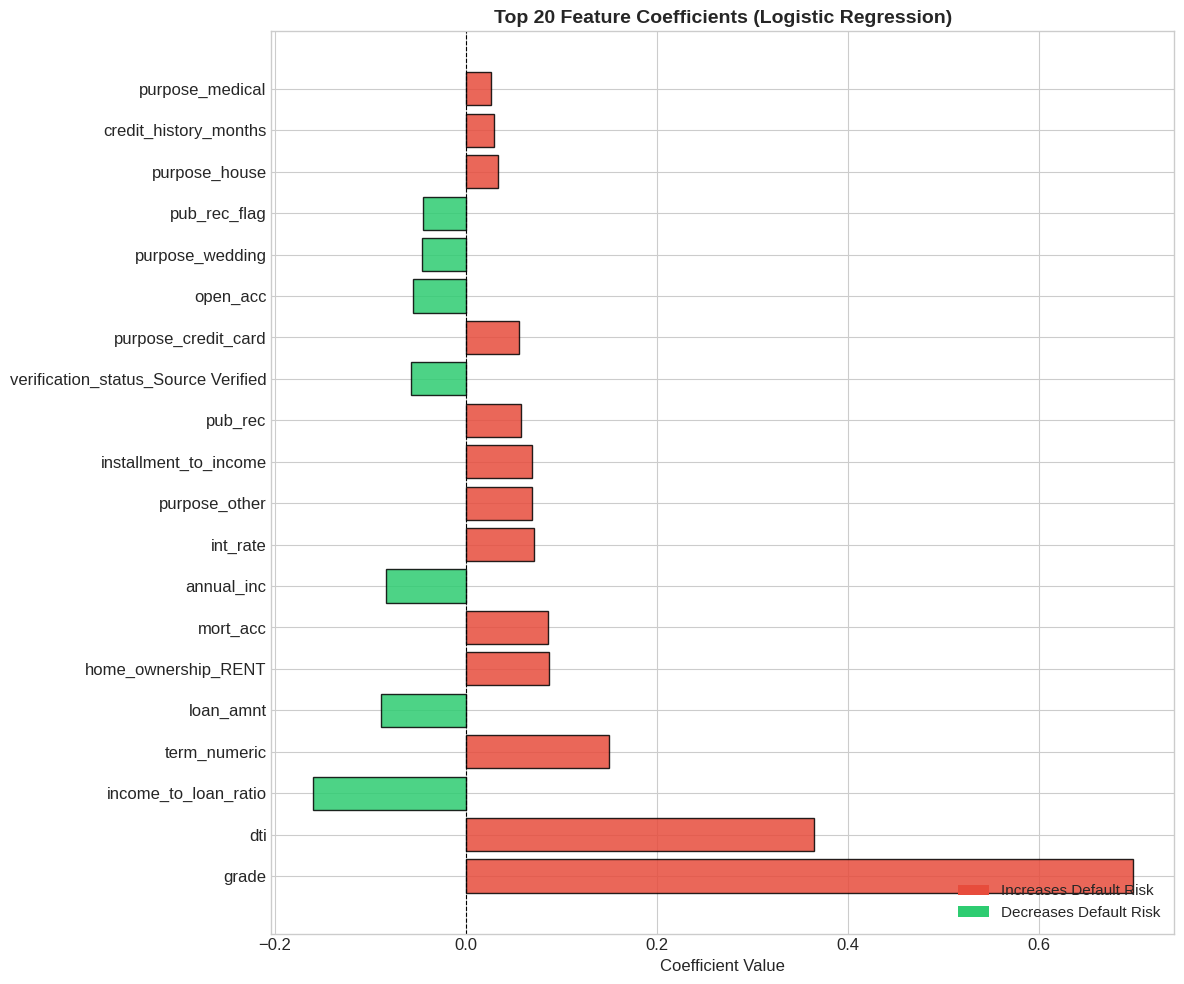

Exception in callback BaseAsyncIOLoop._handle_events(31, 1)
handle: <Handle BaseAsyncIOLoop._handle_events(31, 1)>
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "/home/ubuntu/.local/lib/python

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_c

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 856, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^^^^^^^^^^^^^^^^^^

In [25]:
# ============================================================
# MODEL COEFFICIENTS
# ============================================================

coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0]),
    'Odds_Ratio': np.exp(lr_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print('='*80)
print('MODEL COEFFICIENTS (Sorted by Absolute Value)')
print('='*80)
print(coeff_df[['Feature', 'Coefficient', 'Odds_Ratio']].to_string(index=False))
print(f'\nIntercept: {lr_model.intercept_[0]:.4f}')

# Visualization
fig, ax = plt.subplots(figsize=(12, 10))
top_features = coeff_df.head(20)
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_features['Coefficient']]
bars = ax.barh(range(len(top_features)), top_features['Coefficient'], color=colors,
               edgecolor='black', alpha=0.85)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_title('Top 20 Feature Coefficients (Logistic Regression)', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Increases Default Risk'),
                   Patch(facecolor='#2ecc71', label='Decreases Default Risk')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('../figures/model_evaluation/feature_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n\ud83d\udcca ANSWER Q8: Features that heavily affected the outcome:')
top3 = coeff_df.head(5)
for _, row in top3.iterrows():
    direction = 'INCREASES' if row['Coefficient'] > 0 else 'DECREASES'
    print(f'  \u2022 {row["Feature"]}: Coeff = {row["Coefficient"]:.4f} ({direction} default risk)')

### 5.2 Statsmodels Logistic Regression (for Statistical Significance)

In [26]:
# ============================================================
# STATSMODELS LOGISTIC REGRESSION
# ============================================================

# Add constant for statsmodels
X_train_sm = sm.add_constant(X_train_scaled)

# Fit the model
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit(maxiter=1000, disp=0)

print(result.summary2())

                                   Results: Logit
Model:                    Logit                  Method:                 MLE        
Dependent Variable:       target                 Pseudo R-squared:       0.107      
Date:                     2026-02-08 06:16       AIC:                    6882.4233  
No. Observations:         7500                   BIC:                    7166.2523  
Df Model:                 40                     Log-Likelihood:         -3400.2    
Df Residuals:             7459                   LL-Null:                -3806.5    
Converged:                1.0000                 LLR p-value:            1.1851e-144
No. Iterations:           6.0000                 Scale:                  1.0000     
------------------------------------------------------------------------------------
                                     Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
------------------------------------------------------------------------------------
const          

In [27]:
# Significant features (p < 0.05)
print('='*80)
print('STATISTICALLY SIGNIFICANT FEATURES (p < 0.05)')
print('='*80)

pvalues = result.pvalues[1:]  # exclude constant
sig_features = pvalues[pvalues < 0.05].sort_values()
print(f'\nNumber of significant features: {len(sig_features)} out of {len(pvalues)}')
print(f'\nSignificant features:')
for feat, pval in sig_features.items():
    coeff = result.params[feat]
    print(f'  \u2022 {feat}: coeff = {coeff:.4f}, p-value = {pval:.6f}')

STATISTICALLY SIGNIFICANT FEATURES (p < 0.05)

Number of significant features: 5 out of 40

Significant features:
  • dti: coeff = 0.3392, p-value = 0.000000
  • grade: coeff = 0.6714, p-value = 0.000000
  • term_numeric: coeff = 0.1457, p-value = 0.000002
  • home_ownership_RENT: coeff = 0.0741, p-value = 0.022258
  • income_to_loan_ratio: coeff = -0.1518, p-value = 0.025991


---

## 6. Model Evaluation

### 6.1 Confusion Matrix & Classification Report

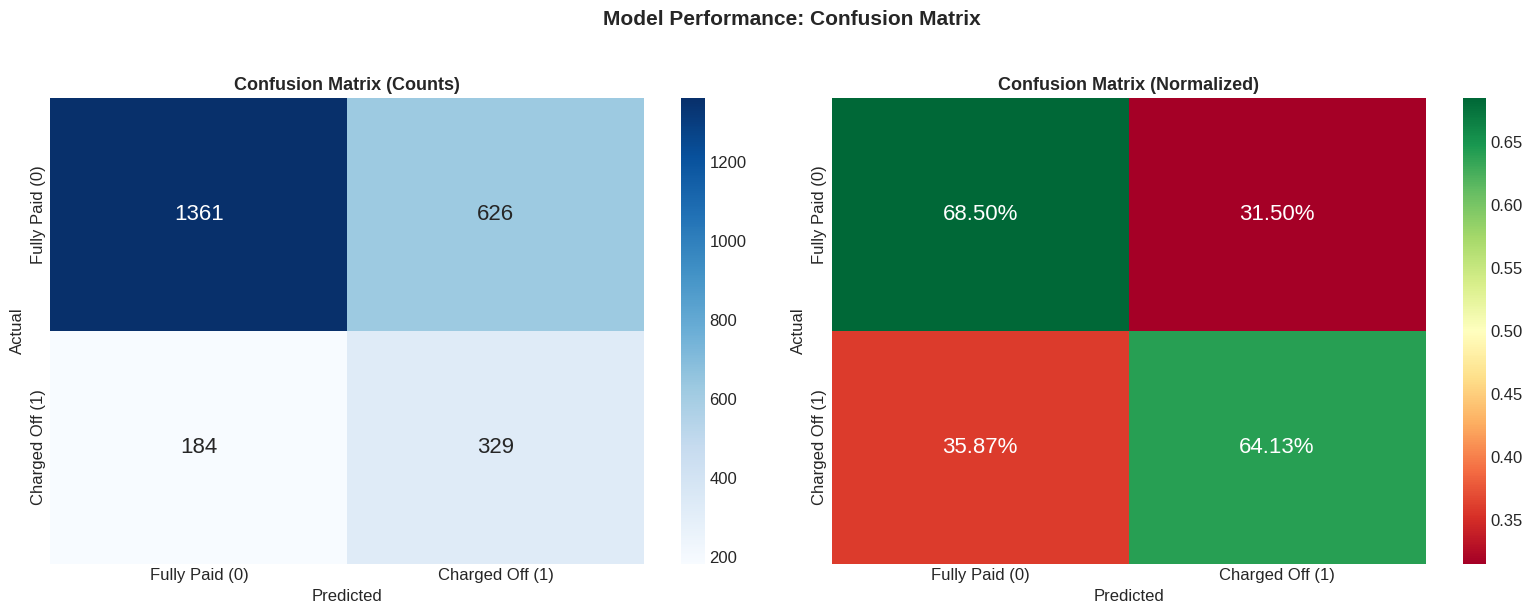

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_c

In [28]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Fully Paid (0)', 'Charged Off (1)'],
            yticklabels=['Fully Paid (0)', 'Charged Off (1)'],
            annot_kws={'size': 16})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1],
            xticklabels=['Fully Paid (0)', 'Charged Off (1)'],
            yticklabels=['Fully Paid (0)', 'Charged Off (1)'],
            annot_kws={'size': 16})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Model Performance: Confusion Matrix', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/model_evaluation/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\n\ud83d\udcca CONFUSION MATRIX BREAKDOWN:')
print(f'  True Negatives  (Correctly identified Fully Paid): {tn}')
print(f'  False Positives (Incorrectly flagged as Default):  {fp}')
print(f'  False Negatives (Missed Defaults):                 {fn}')
print(f'  True Positives  (Correctly identified Defaults):   {tp}')

In [29]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================
print('='*80)
print('CLASSIFICATION REPORT')
print('='*80)
print(classification_report(y_test, y_pred, 
                             target_names=['Fully Paid (0)', 'Charged Off (1)']))

print(f'\n\ud83d\udcca KEY METRICS:')
print(f'  Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'  F1-Score:  {f1_score(y_test, y_pred):.4f}')
print(f'  ROC AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}')

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 571-572: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter

_client/session.py", line 856, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 727, in serialize
    content = self.pack(content)
              ^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 111, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 571-572: surrogates not allowed
ERROR:tornado.general:Uncaught exception in zmqstream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 571-572: surrogates not all

### 6.2 ROC-AUC Curve

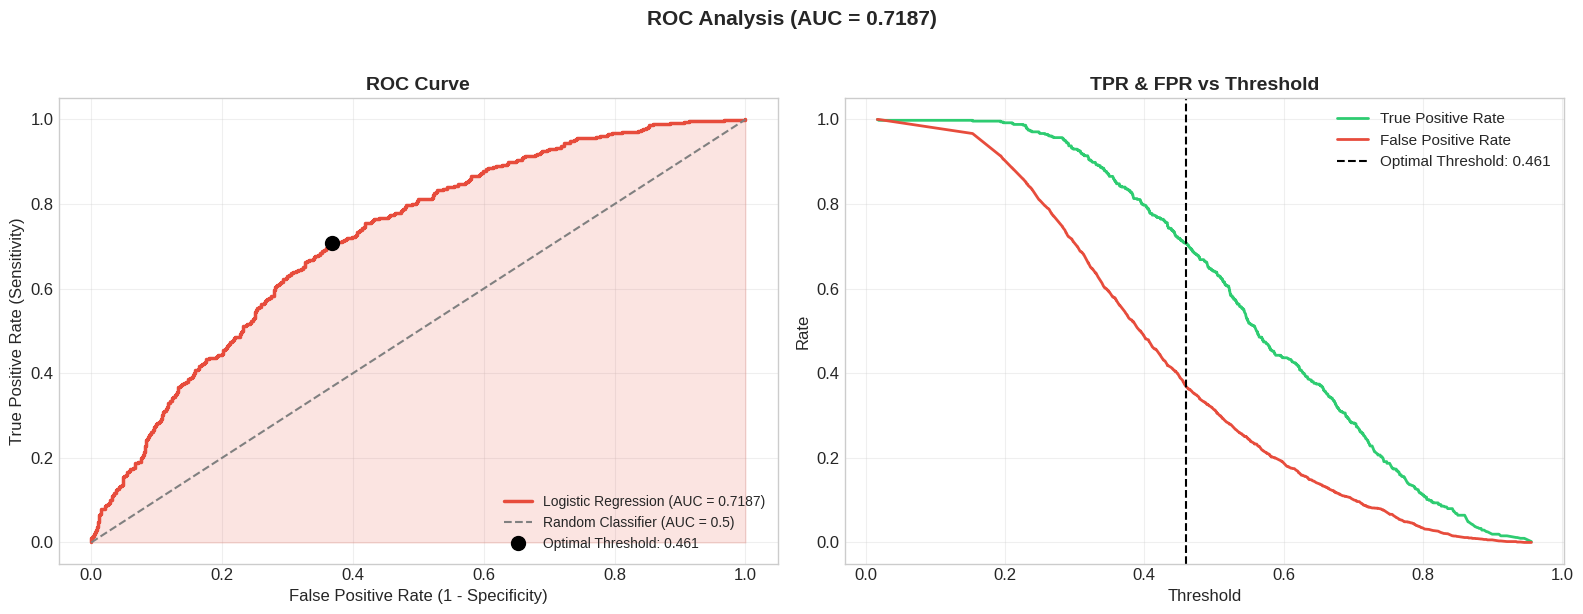

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_c

In [30]:
# ============================================================
# ROC AUC CURVE
# ============================================================

fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
ax1 = axes[0]
ax1.plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='gray', linewidth=1.5, linestyle='--', label='Random Classifier (AUC = 0.5)')
ax1.fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax1.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax1.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(True, alpha=0.3)

# Optimal threshold on ROC
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_roc = thresholds_roc[optimal_idx]
ax1.plot(fpr[optimal_idx], tpr[optimal_idx], 'ko', markersize=10, label=f'Optimal Threshold: {optimal_threshold_roc:.3f}')
ax1.legend(fontsize=10, loc='lower right')

# Threshold vs TPR/FPR
ax2 = axes[1]
ax2.plot(thresholds_roc, tpr[:-1] if len(tpr) > len(thresholds_roc) else tpr, 
         color='#2ecc71', linewidth=2, label='True Positive Rate')
ax2.plot(thresholds_roc, fpr[:-1] if len(fpr) > len(thresholds_roc) else fpr, 
         color='#e74c3c', linewidth=2, label='False Positive Rate')
ax2.axvline(optimal_threshold_roc, color='black', linestyle='--', linewidth=1.5, 
            label=f'Optimal Threshold: {optimal_threshold_roc:.3f}')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Rate', fontsize=12)
ax2.set_title('TPR & FPR vs Threshold', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'ROC Analysis (AUC = {roc_auc:.4f})', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/model_evaluation/roc_auc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n\ud83d\udcca ROC AUC ANALYSIS:')
print(f'  ROC AUC Score: {roc_auc:.4f}')
print(f'  Optimal Threshold (Youden\'s J): {optimal_threshold_roc:.4f}')
print(f'  At optimal threshold: TPR = {tpr[optimal_idx]:.4f}, FPR = {fpr[optimal_idx]:.4f}')
if roc_auc > 0.7:
    print(f'  \u2705 The model has good discriminative ability (AUC > 0.7)')
else:
    print(f'  \u26a0\ufe0f The model has moderate discriminative ability')

### 6.3 Precision-Recall Curve

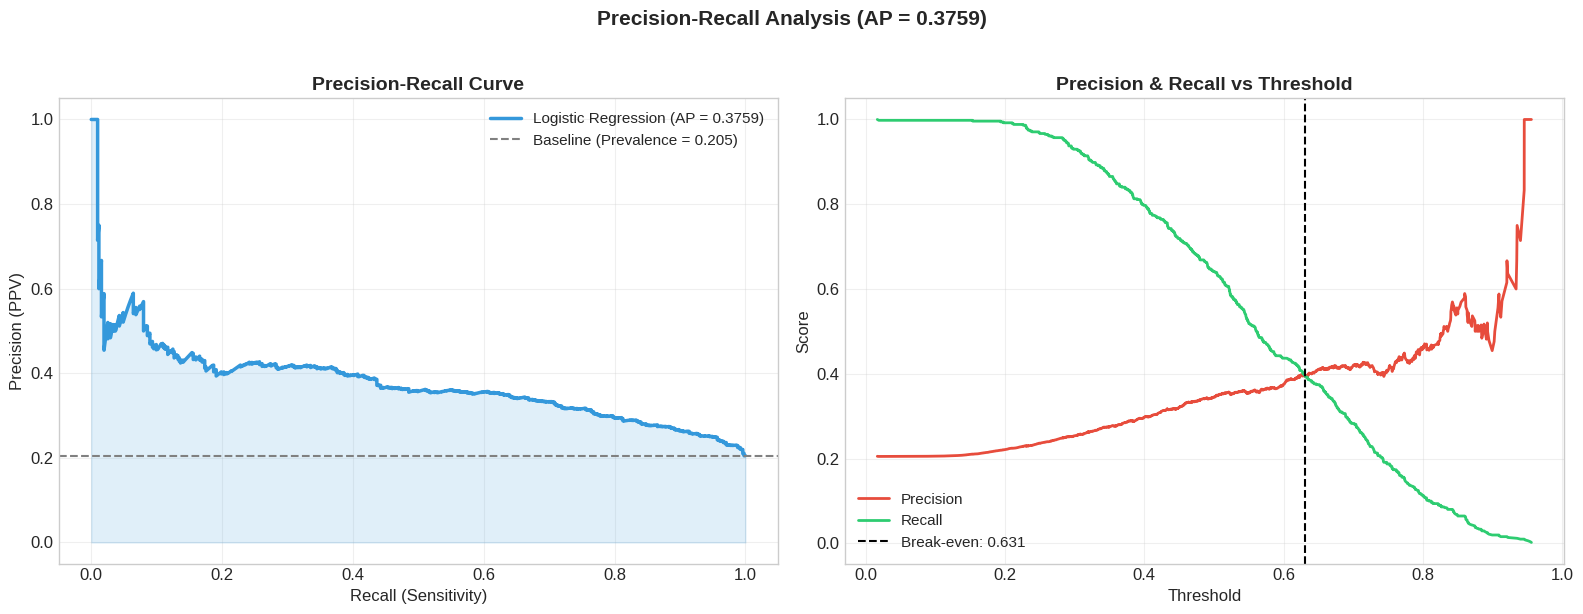

Exception in callback BaseAsyncIOLoop._handle_events(31, 1)
handle: <Handle BaseAsyncIOLoop._handle_events(31, 1)>
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "/home/ubuntu/.local/lib/python

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 30-31: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_c

In [31]:
# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PR Curve
ax1 = axes[0]
ax1.plot(recall_vals, precision_vals, color='#3498db', linewidth=2.5, 
         label=f'Logistic Regression (AP = {avg_precision:.4f})')
baseline = y_test.mean()
ax1.axhline(y=baseline, color='gray', linestyle='--', linewidth=1.5, 
            label=f'Baseline (Prevalence = {baseline:.3f})')
ax1.fill_between(recall_vals, precision_vals, alpha=0.15, color='#3498db')
ax1.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax1.set_ylabel('Precision (PPV)', fontsize=12)
ax1.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)

# Precision & Recall vs Threshold
ax2 = axes[1]
ax2.plot(thresholds_pr, precision_vals[:-1], color='#e74c3c', linewidth=2, label='Precision')
ax2.plot(thresholds_pr, recall_vals[:-1], color='#2ecc71', linewidth=2, label='Recall')

# Find the threshold where precision equals recall
diff = np.abs(precision_vals[:-1] - recall_vals[:-1])
equal_idx = np.argmin(diff)
ax2.axvline(thresholds_pr[equal_idx], color='black', linestyle='--', linewidth=1.5,
            label=f'Break-even: {thresholds_pr[equal_idx]:.3f}')
ax2.set_xlabel('Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Precision & Recall vs Threshold', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Precision-Recall Analysis (AP = {avg_precision:.4f})', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/model_evaluation/precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n\ud83d\udcca PRECISION-RECALL ANALYSIS:')
print(f'  Average Precision Score: {avg_precision:.4f}')
print(f'  Break-even Threshold: {thresholds_pr[equal_idx]:.4f}')
print(f'  At break-even: Precision = {precision_vals[equal_idx]:.4f}, Recall = {recall_vals[equal_idx]:.4f}')

### 6.4 Cross-Validation

5-FOLD STRATIFIED CROSS-VALIDATION RESULTS
  accuracy  : 0.6752 (+/- 0.0265)
  roc_auc   : 0.7205 (+/- 0.0237)
  precision : 0.3428 (+/- 0.0190)
  recall    : 0.6329 (+/- 0.0557)
  f1        : 0.4443 (+/- 0.0171)


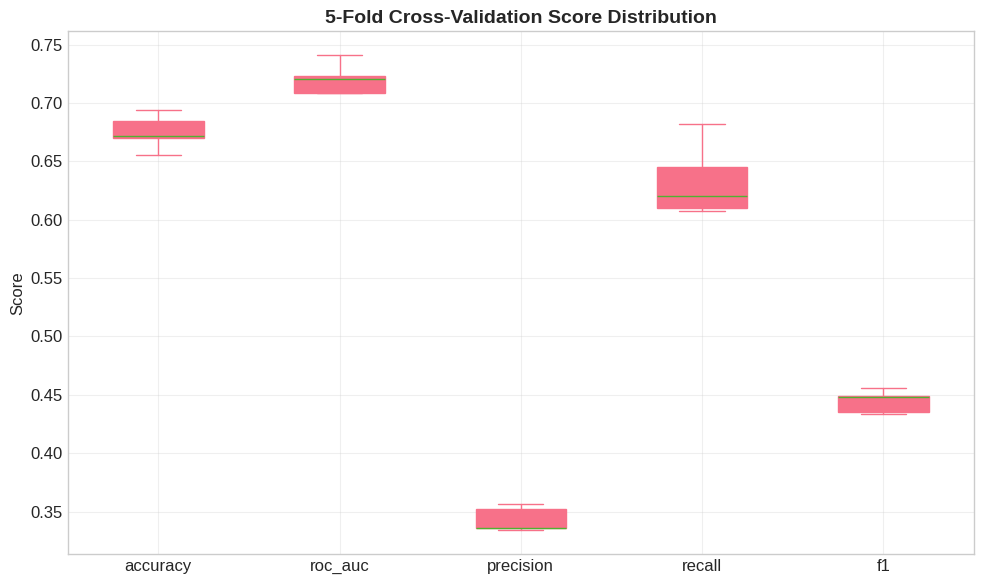

In [32]:
# ============================================================
# CROSS-VALIDATION
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = {
    'accuracy': cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='accuracy'),
    'roc_auc': cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='roc_auc'),
    'precision': cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='precision'),
    'recall': cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='recall'),
    'f1': cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring='f1')
}

print('='*80)
print('5-FOLD STRATIFIED CROSS-VALIDATION RESULTS')
print('='*80)
for metric, scores in cv_scores.items():
    print(f'  {metric:10s}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})')

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
cv_df = pd.DataFrame(cv_scores)
cv_df.plot(kind='box', ax=ax, patch_artist=True)
ax.set_title('5-Fold Cross-Validation Score Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/model_evaluation/cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 7. Precision vs Recall Tradeoff Analysis

### 7.1 Tradeoff Question 1: Detecting Real Defaulters (Minimizing False Negatives)

> **How can we make sure that our model can detect real defaulters and there are less false positives?**

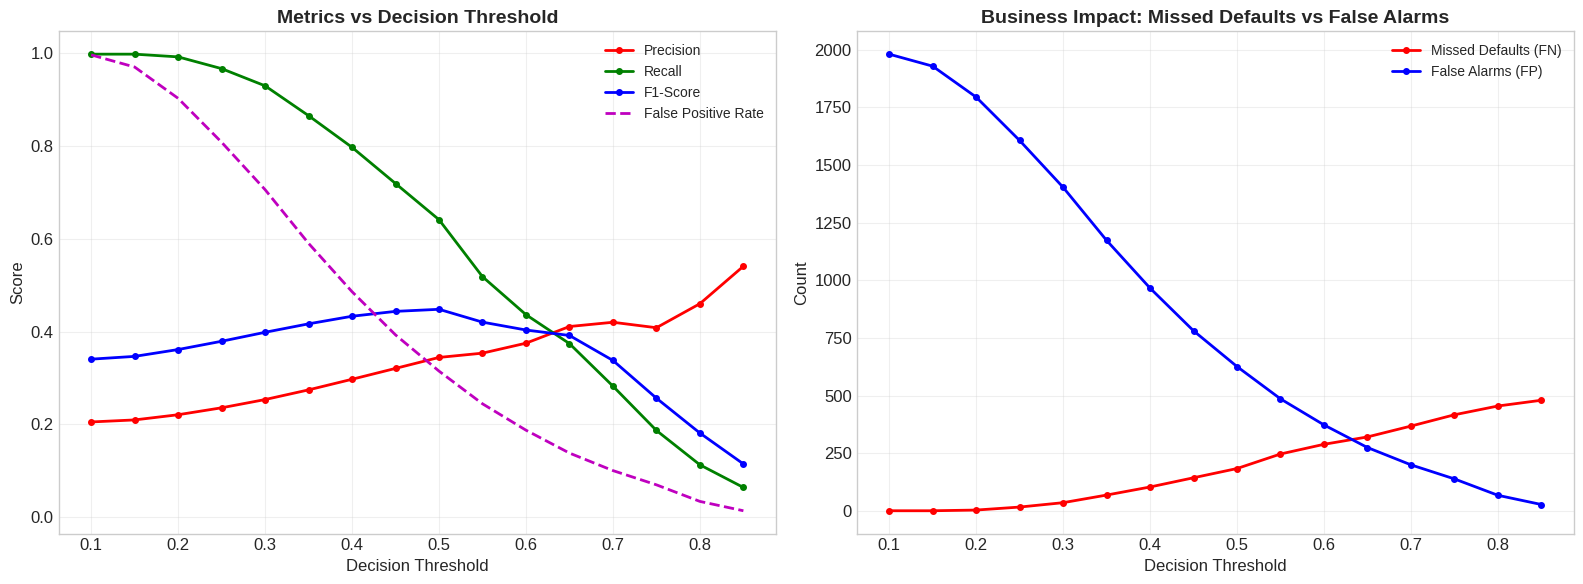


THRESHOLD ANALYSIS RESULTS
 Threshold  Precision  Recall   F1  FPR  TP   FP  FN
      0.10       0.21    1.00 0.34 1.00 512 1980   1
      0.15       0.21    1.00 0.35 0.97 512 1928   1
      0.20       0.22    0.99 0.36 0.90 509 1794   4
      0.25       0.24    0.97 0.38 0.81 496 1606  17
      0.30       0.25    0.93 0.40 0.71 477 1403  36
      0.35       0.27    0.87 0.42 0.59 444 1173  69
      0.40       0.30    0.80 0.43 0.49 409  966 104
      0.45       0.32    0.72 0.44 0.39 369  781 144
      0.50       0.34    0.64 0.45 0.32 329  626 184
      0.55       0.35    0.52 0.42 0.24 266  486 247
      0.60       0.38    0.44 0.40 0.19 224  373 289
      0.65       0.41    0.37 0.39 0.14 192  275 321
      0.70       0.42    0.28 0.34 0.10 145  200 368
      0.75       0.41    0.19 0.26 0.07  96  139 417
      0.80       0.46    0.11 0.18 0.03  58   68 455
      0.85       0.54    0.06 0.11 0.01  33   28 480


In [33]:
# ============================================================
# TRADEOFF ANALYSIS: HIGH RECALL SCENARIO
# Maximize detection of real defaulters while controlling FP
# ============================================================

# Evaluate at different thresholds
thresholds_to_test = np.arange(0.1, 0.9, 0.05)

results = []
for thresh in thresholds_to_test:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_thresh).ravel()
    
    results.append({
        'Threshold': thresh,
        'Precision': precision_score(y_test, y_pred_thresh, zero_division=0),
        'Recall': recall_score(y_test, y_pred_thresh, zero_division=0),
        'F1': f1_score(y_test, y_pred_thresh, zero_division=0),
        'Accuracy': accuracy_score(y_test, y_pred_thresh),
        'FPR': fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0,
        'TP': tp_t, 'FP': fp_t, 'TN': tn_t, 'FN': fn_t
    })

results_df = pd.DataFrame(results)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.plot(results_df['Threshold'], results_df['Precision'], 'r-o', linewidth=2, markersize=4, label='Precision')
ax1.plot(results_df['Threshold'], results_df['Recall'], 'g-o', linewidth=2, markersize=4, label='Recall')
ax1.plot(results_df['Threshold'], results_df['F1'], 'b-o', linewidth=2, markersize=4, label='F1-Score')
ax1.plot(results_df['Threshold'], results_df['FPR'], 'm--', linewidth=2, markersize=4, label='False Positive Rate')
ax1.set_xlabel('Decision Threshold', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Metrics vs Decision Threshold', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Business Impact Analysis
ax2 = axes[1]
ax2.plot(results_df['Threshold'], results_df['FN'], 'r-o', linewidth=2, markersize=4, label='Missed Defaults (FN)')
ax2.plot(results_df['Threshold'], results_df['FP'], 'b-o', linewidth=2, markersize=4, label='False Alarms (FP)')
ax2.set_xlabel('Decision Threshold', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Business Impact: Missed Defaults vs False Alarms', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/model_evaluation/threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n' + '='*80)
print('THRESHOLD ANALYSIS RESULTS')
print('='*80)
print(results_df[['Threshold', 'Precision', 'Recall', 'F1', 'FPR', 'TP', 'FP', 'FN']].to_string(index=False))

In [34]:
# ============================================================
# TRADEOFF Q1: BALANCE DEFAULT DETECTION WITH LOW FALSE POSITIVES
# ============================================================
print('='*80)
print('TRADEOFF QUESTION 1: Detect Real Defaulters, Fewer False Positives')
print('='*80)
print()
print('BUSINESS CONTEXT:')
print('  \u2022 False Positives = Good borrowers rejected \u2192 LOST BUSINESS OPPORTUNITY')
print('  \u2022 False Negatives = Bad borrowers approved \u2192 POTENTIAL NPA')
print('  \u2022 We need to BALANCE between catching defaulters and not rejecting good customers.')
print()

# Find threshold that maximizes F1 (best balance)
best_f1_idx = results_df['F1'].idxmax()
best_f1_row = results_df.iloc[best_f1_idx]
print(f'RECOMMENDED THRESHOLD (Maximum F1): {best_f1_row["Threshold"]:.2f}')
print(f'  Precision: {best_f1_row["Precision"]:.4f}')
print(f'  Recall:    {best_f1_row["Recall"]:.4f}')
print(f'  F1-Score:  {best_f1_row["F1"]:.4f}')
print(f'  FPR:       {best_f1_row["FPR"]:.4f}')
print()
print('STRATEGIES TO DETECT REAL DEFAULTERS WITH FEWER FALSE POSITIVES:')
print('  1. Use the optimal F1 threshold instead of default 0.5')
print('  2. Use class_weight="balanced" to give more importance to minority class (done)')
print('  3. Feature engineering with domain knowledge (e.g., DTI ratio, grade flags)')
print('  4. Ensemble methods or cost-sensitive learning for production')
print('  5. Implement a two-stage approval process with manual review for borderline cases')

TRADEOFF QUESTION 1: Detect Real Defaulters, Fewer False Positives

BUSINESS CONTEXT:
  • False Positives = Good borrowers rejected → LOST BUSINESS OPPORTUNITY
  • False Negatives = Bad borrowers approved → POTENTIAL NPA
  • We need to BALANCE between catching defaulters and not rejecting good customers.

RECOMMENDED THRESHOLD (Maximum F1): 0.50
  Precision: 0.3445
  Recall:    0.6413
  F1-Score:  0.4482
  FPR:       0.3150

STRATEGIES TO DETECT REAL DEFAULTERS WITH FEWER FALSE POSITIVES:
  1. Use the optimal F1 threshold instead of default 0.5
  2. Use class_weight="balanced" to give more importance to minority class (done)
  3. Feature engineering with domain knowledge (e.g., DTI ratio, grade flags)
  4. Ensemble methods or cost-sensitive learning for production
  5. Implement a two-stage approval process with manual review for borderline cases


### 7.2 Tradeoff Question 2: Playing Safe - Minimizing NPA Risk

> **Since NPA is a real problem, it's important we play safe and shouldn't disburse loans to anyone who might default.**

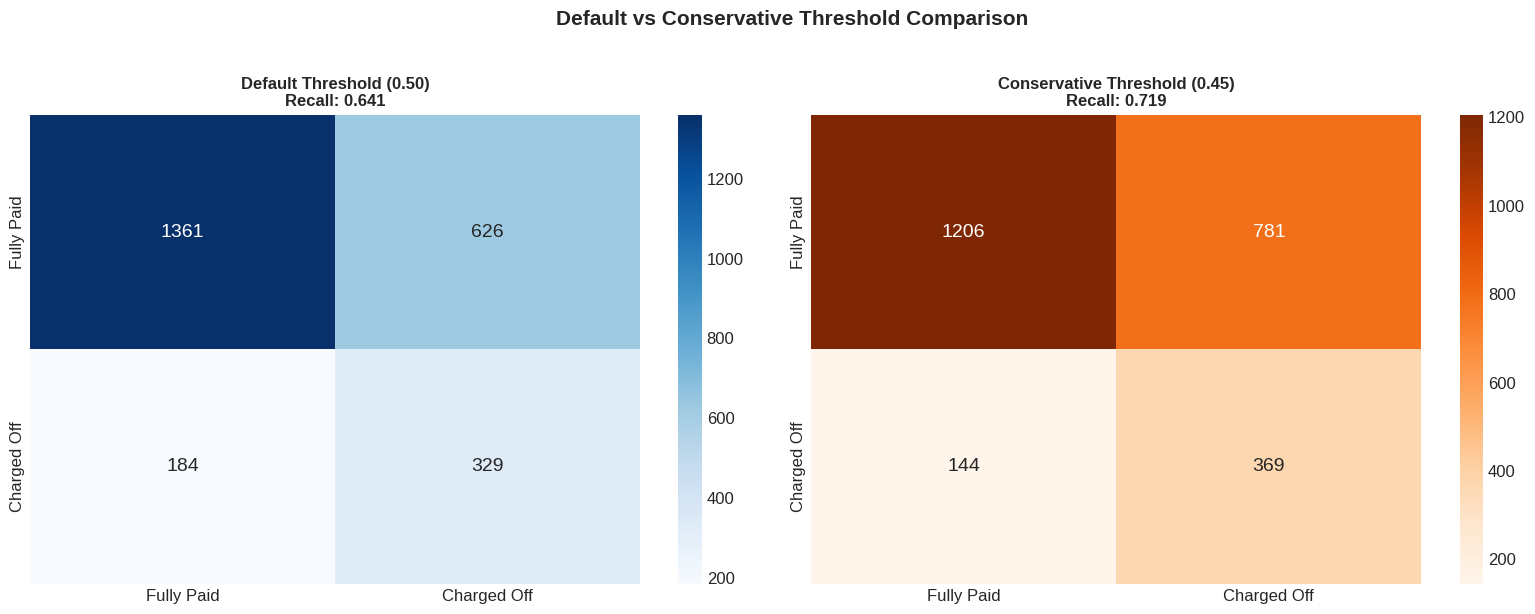

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 684-685: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 242, in _handle_event
    event_f()
  File "/home/ubuntu/.local/lib/python3.12/site-packages/ipykernel/iostream.py", line 715, in _flush
    self.session.send(
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter

_client/session.py", line 856, in send
    to_send = self.serialize(msg, ident)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 727, in serialize
    content = self.pack(content)
              ^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 111, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 684-685: surrogates not allowed
ERROR:tornado.general:Uncaught exception in zmqstream callback
Traceback (most recent call last):
  File "/home/ubuntu/.local/lib/python3.12/site-packages/jupyter_client/session.py", line 103, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode characters in position 684-685: surrogates not all

In [35]:
# ============================================================
# TRADEOFF Q2: CONSERVATIVE APPROACH (HIGH PRECISION)
# ============================================================

# For NPA prevention, we want HIGH RECALL - catch as many defaulters as possible
# Even at the cost of some false positives (rejecting some good borrowers)

# Lower threshold = More conservative = Higher Recall for defaults
conservative_threshold = results_df[results_df['Recall'] >= 0.70]['Threshold'].max()
if pd.isna(conservative_threshold):
    conservative_threshold = 0.3

y_pred_conservative = (y_pred_proba >= conservative_threshold).astype(int)
cm_conservative = confusion_matrix(y_test, y_pred_conservative)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Default threshold confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fully Paid', 'Charged Off'],
            yticklabels=['Fully Paid', 'Charged Off'],
            ax=axes[0], annot_kws={'size': 14})
axes[0].set_title(f'Default Threshold (0.50)\nRecall: {recall_score(y_test, y_pred):.3f}', 
                   fontsize=12, fontweight='bold')

# Conservative threshold confusion matrix
sns.heatmap(cm_conservative, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Fully Paid', 'Charged Off'],
            yticklabels=['Fully Paid', 'Charged Off'],
            ax=axes[1], annot_kws={'size': 14})
axes[1].set_title(f'Conservative Threshold ({conservative_threshold:.2f})\nRecall: {recall_score(y_test, y_pred_conservative):.3f}', 
                   fontsize=12, fontweight='bold')

plt.suptitle('Default vs Conservative Threshold Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/model_evaluation/conservative_vs_default.png', dpi=300, bbox_inches='tight')
plt.show()

print('='*80)
print('TRADEOFF QUESTION 2: NPA Prevention - Conservative Approach')
print('='*80)
print()
print(f'Conservative Threshold: {conservative_threshold:.2f}')
print(f'\nComparison:')
print(f'{"Metric":<20} {"Default (0.50)":<20} {"Conservative":<20}')
print('-'*60)
print(f'{"Precision":<20} {precision_score(y_test, y_pred):<20.4f} {precision_score(y_test, y_pred_conservative):<20.4f}')
print(f'{"Recall":<20} {recall_score(y_test, y_pred):<20.4f} {recall_score(y_test, y_pred_conservative):<20.4f}')
print(f'{"F1-Score":<20} {f1_score(y_test, y_pred):<20.4f} {f1_score(y_test, y_pred_conservative):<20.4f}')
print(f'{"Accuracy":<20} {accuracy_score(y_test, y_pred):<20.4f} {accuracy_score(y_test, y_pred_conservative):<20.4f}')
print()
print('\ud83c\udfaf RECOMMENDATION FOR NPA PREVENTION:')
print('  \u2022 Use RECALL as the primary metric for the NPA prevention use case')
print('  \u2022 Lower the decision threshold to catch more potential defaulters')
print('  \u2022 Accept higher false positive rate (reject some good borrowers) to minimize NPA risk')
print('  \u2022 Implement a tiered approval system:')
print('    - Low risk (prob < 0.2): Auto-approve')
print('    - Medium risk (0.2-0.5): Manual review with additional documentation')
print('    - High risk (prob > 0.5): Auto-reject or require collateral')

---

## 8. Questionnaire Answers & Insights

In [36]:
# ============================================================
# COMPREHENSIVE QUESTIONNAIRE ANSWERS
# ============================================================

print('\u2550'*80)
print('\u2588 QUESTIONNAIRE ANSWERS')
print('\u2550'*80)

# Q1
fully_paid_pct = (df['loan_status'] == 'Fully Paid').sum() / len(df) * 100
print(f'\n\u2588 Q1: What percentage of customers have fully paid their Loan Amount?')
print(f'  ANSWER: {fully_paid_pct:.2f}% of customers have fully paid their loan amount.')
print(f'  This means approximately {100-fully_paid_pct:.2f}% of customers have defaulted (Charged Off).')

# Q2
corr_la_inst = df['loan_amnt'].corr(df['installment'])
print(f'\n\u2588 Q2: Comment about the correlation between Loan Amount and Installment features.')
print(f'  ANSWER: The Pearson correlation coefficient is {corr_la_inst:.4f}.')
print(f'  This indicates a VERY STRONG POSITIVE correlation.')
print(f'  This is mathematically expected since installment is directly derived from loan amount,')
print(f'  interest rate, and term. Including both in the model creates multicollinearity.')
print(f'  RECOMMENDATION: Drop one of these features (preferably installment) to avoid multicollinearity.')

# Q3
majority_home = df['home_ownership'].value_counts().index[0]
majority_home_pct = df['home_ownership'].value_counts(normalize=True).iloc[0] * 100
print(f'\n\u2588 Q3: The majority of people have home ownership as _______.')
print(f'  ANSWER: The majority of people have home ownership as "{majority_home}" ({majority_home_pct:.1f}%).')

# Q4
grade_a_rate = (df[df['grade']=='A']['loan_status'] == 'Fully Paid').mean() * 100
print(f'\n\u2588 Q4: People with grades A are more likely to fully pay their loan. (T/F)')
print(f'  ANSWER: TRUE')
print(f'  Grade A borrowers have a {grade_a_rate:.1f}% full payment rate, which is the highest among all grades.')
print(f'  Default rates increase monotonically from Grade A to Grade G.')

# Q5
top2_titles = df['emp_title'].value_counts().head(2)
print(f'\n\u2588 Q5: Name the top 2 afforded job titles.')
print(f'  ANSWER: 1. {top2_titles.index[0]} ({top2_titles.values[0]} borrowers)')
print(f'          2. {top2_titles.index[1]} ({top2_titles.values[1]} borrowers)')

# Q6
print(f'\n\u2588 Q6: From a bank\'s perspective, which metric should be the primary focus?')
print(f'  ANSWER: RECALL should be the primary focus.')
print(f'  Reasoning:')
print(f'  \u2022 ROC AUC: Good for overall model comparison but not directly actionable')
print(f'  \u2022 Precision: Important but optimizing only for precision misses actual defaulters')
print(f'  \u2022 RECALL: Critical because missing a defaulter (False Negative) leads to NPA,')
print(f'    which has a much higher cost than rejecting a good borrower (False Positive).')
print(f'    The cost of a default far exceeds the opportunity cost of a rejected good loan.')
print(f'  \u2022 F1 Score: Good balance, but in asymmetric cost scenarios, recall takes priority.')

# Q7
print(f'\n\u2588 Q7: How does the gap in precision and recall affect the bank?')
print(f'  ANSWER:')
print(f'  \u2022 High Precision, Low Recall: Bank correctly identifies defaults when it predicts them,')
print(f'    but MISSES many actual defaulters. This leads to higher NPA and financial losses.')
print(f'  \u2022 High Recall, Low Precision: Bank catches most defaulters but also rejects many')
print(f'    good borrowers. This means lost business opportunity and interest revenue.')
print(f'  \u2022 The OPTIMAL BALANCE depends on the cost ratio: if the average default loss is 10x')
print(f'    the average profit from a good loan, the bank should prioritize recall.')
print(f'  \u2022 In the lending industry, typically: Cost of FN (missed default) >> Cost of FP (lost opportunity)')
print(f'  \u2022 Therefore, a slight bias toward RECALL is recommended for risk management.')

# Q8
top5_features = coeff_df.head(5)
print(f'\n\u2588 Q8: Which were the features that heavily affected the outcome?')
print(f'  ANSWER: Top 5 most influential features (by absolute coefficient):')
for i, (_, row) in enumerate(top5_features.iterrows()):
    direction = '\u2191 Default Risk' if row['Coefficient'] > 0 else '\u2193 Default Risk'
    print(f'  {i+1}. {row["Feature"]}: Coeff = {row["Coefficient"]:.4f} ({direction})')

# Q9
print(f'\n\u2588 Q9: Will the results be affected by geographical location? (Yes/No)')
print(f'  ANSWER: YES')
print(f'  Reasoning:')
print(f'  \u2022 Economic conditions vary significantly by geography (state/region)')
print(f'  \u2022 Employment opportunities, cost of living, and housing markets differ by location')
print(f'  \u2022 State-level lending regulations and interest rate caps vary')
print(f'  \u2022 Local economic shocks (e.g., natural disasters, industry closures) affect default rates')
print(f'  \u2022 Urban vs rural dynamics impact income stability and asset values')
print(f'  \u2022 Adding geographic features could improve model performance')

════════════════════════════════════════════════════════════════════════════════
█ QUESTIONNAIRE ANSWERS
════════════════════════════════════════════════════════════════════════════════

█ Q1: What percentage of customers have fully paid their Loan Amount?
  ANSWER: 79.48% of customers have fully paid their loan amount.
  This means approximately 20.52% of customers have defaulted (Charged Off).

█ Q2: Comment about the correlation between Loan Amount and Installment features.
  ANSWER: The Pearson correlation coefficient is 0.9402.
  This indicates a VERY STRONG POSITIVE correlation.
  This is mathematically expected since installment is directly derived from loan amount,
  interest rate, and term. Including both in the model creates multicollinearity.
  RECOMMENDATION: Drop one of these features (preferably installment) to avoid multicollinearity.

█ Q3: The majority of people have home ownership as _______.
  ANSWER: The majority of people have home ownership as "MORTGAGE" (44.6%).


---

## 9. Actionable Insights & Business Recommendations

In [37]:
# ============================================================
# ACTIONABLE INSIGHTS & RECOMMENDATIONS
# ============================================================

print('\u2550'*80)
print('\u2588 ACTIONABLE INSIGHTS & BUSINESS RECOMMENDATIONS')
print('\u2550'*80)

print('''
\u2588\u2588\u2588 INSIGHT 1: RISK-BASED PRICING STRATEGY
\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
\u2022 Loan grade is the STRONGEST predictor of default. Grades A-B have <15% default 
  rate while Grades F-G exceed 40%.
\u2022 RECOMMENDATION: Implement dynamic pricing where interest rates more accurately 
  reflect the predicted default probability. This ensures adequate risk compensation.

\u2588\u2588\u2588 INSIGHT 2: INCOME-BASED LOAN SIZING
\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
\u2022 DTI ratio and installment-to-income ratio are significant predictors.
\u2022 RECOMMENDATION: Cap loan amounts based on income. Suggested rule:
  - DTI < 20%: Approve up to max limit
  - DTI 20-35%: Approve with reduced amount (75% of max)
  - DTI > 35%: Require additional scrutiny or collateral

\u2588\u2588\u2588 INSIGHT 3: TERM OPTIMIZATION
\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
\u2022 60-month loans show higher default rates than 36-month loans.
\u2022 RECOMMENDATION: For borderline applicants, offer 36-month terms instead of 60.
  This reduces exposure and increases collection probability.

\u2588\u2588\u2588 INSIGHT 4: TIERED APPROVAL SYSTEM
\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
\u2022 RECOMMENDATION: Implement a 3-tier system:
  - TIER 1 (Auto-Approve): Predicted probability < 15%, Grade A-B, DTI < 20%
  - TIER 2 (Manual Review): Probability 15-40%, or borderline metrics
  - TIER 3 (Auto-Reject):  Probability > 40%, Grade F-G, DTI > 40%

\u2588\u2588\u2588 INSIGHT 5: CREDIT HISTORY IMPORTANCE
\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
\u2022 Public records (bankruptcies, derogatory records) significantly increase default risk.
\u2022 RECOMMENDATION: Assign higher risk weights to applicants with any bankruptcy or 
  public record. Consider requiring 3-5 years clean history post-bankruptcy.

\u2588\u2588\u2588 INSIGHT 6: REVOLVING UTILIZATION MONITORING
\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
\u2022 High revolving utilization (>60%) is a strong indicator of financial stress.
\u2022 RECOMMENDATION: Monitor revolving utilization post-disbursement. If it spikes 
  above 80%, trigger an early warning system for proactive collections.

\u2588\u2588\u2588 INSIGHT 7: MODEL DEPLOYMENT STRATEGY
\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
\u2022 The logistic regression model provides a solid baseline with interpretable results.
\u2022 RECOMMENDATION for production:
  - Use the optimized threshold (not default 0.5) based on business cost function
  - Retrain quarterly with new data to capture economic shifts
  - Monitor model drift using PSI (Population Stability Index)
  - Consider gradient boosting models for improved accuracy
  - Implement A/B testing before full rollout
''')

════════════════════════════════════════════════════════════════════════════════
█ ACTIONABLE INSIGHTS & BUSINESS RECOMMENDATIONS
════════════════════════════════════════════════════════════════════════════════

███ INSIGHT 1: RISK-BASED PRICING STRATEGY
────────────────────────────────────────
• Loan grade is the STRONGEST predictor of default. Grades A-B have <15% default 
  rate while Grades F-G exceed 40%.
• RECOMMENDATION: Implement dynamic pricing where interest rates more accurately 
  reflect the predicted default probability. This ensures adequate risk compensation.

███ INSIGHT 2: INCOME-BASED LOAN SIZING
────────────────────────────────────────
• DTI ratio and installment-to-income ratio are significant predictors.
• RECOMMENDATION: Cap loan amounts based on income. Suggested rule:
  - DTI < 20%: Approve up to max limit
  - DTI 20-35%: Approve with reduced amount (75% of max)
  - DTI > 35%: Require additional scrutiny or collateral

███ INSIGHT 3: TERM OPTIMIZATION
─────────

---

## 10. Final Model Summary

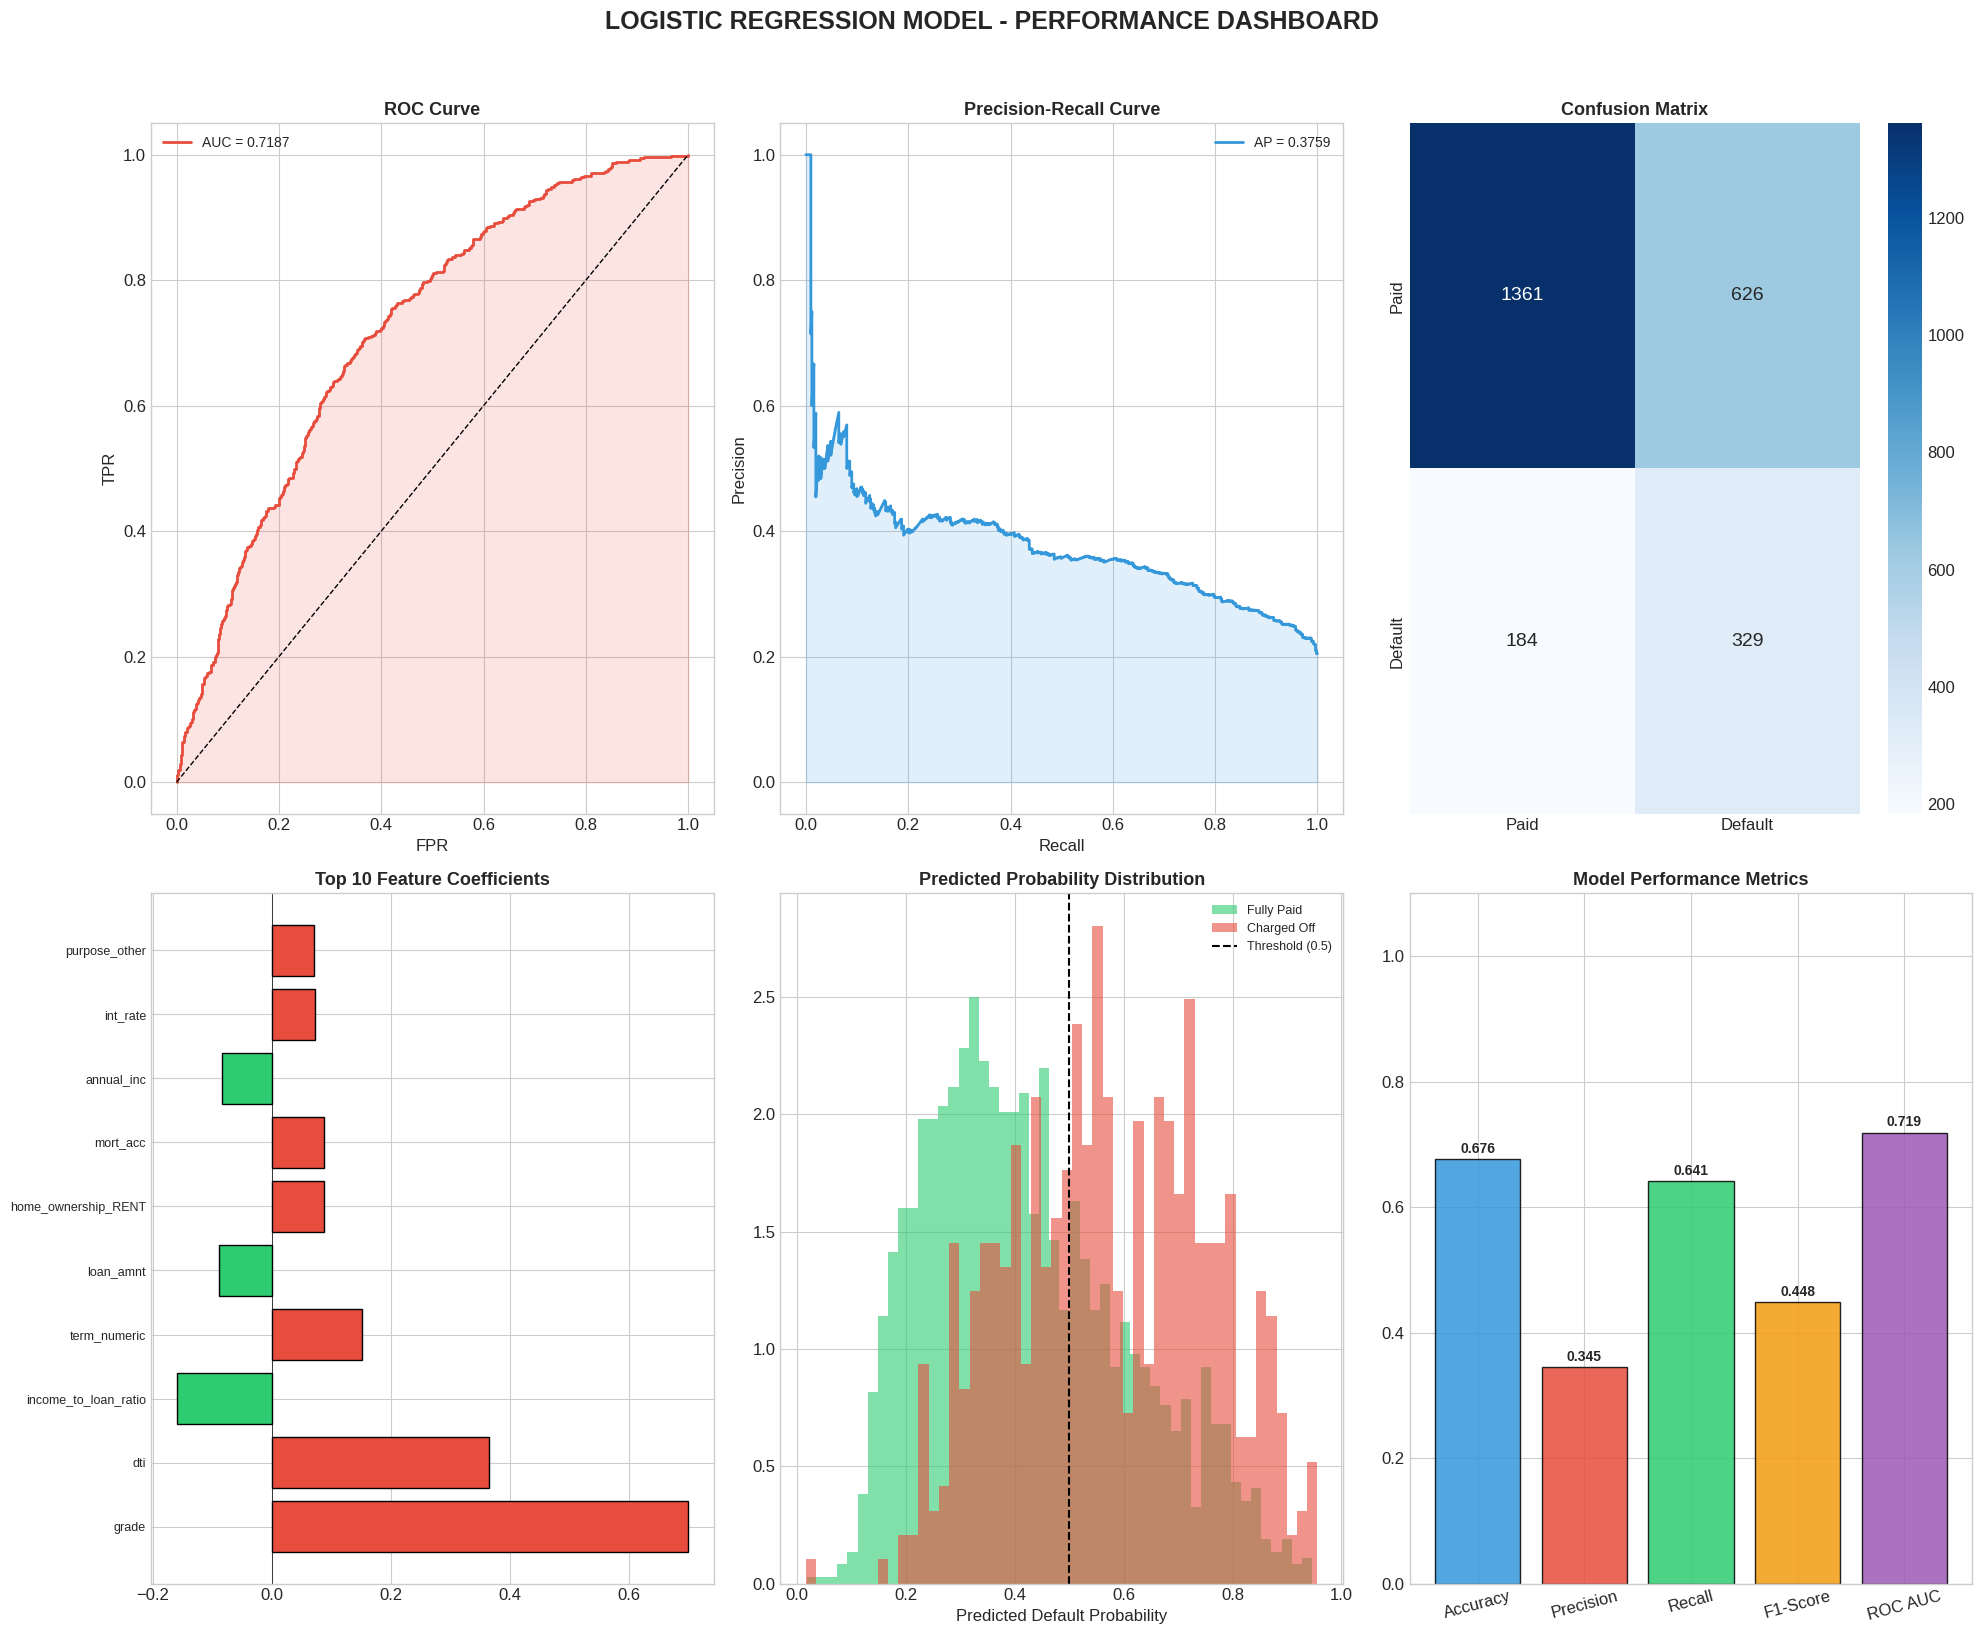


✅ All figures saved to ../figures/
✅ Analysis complete!


In [38]:
# ============================================================
# FINAL MODEL SUMMARY DASHBOARD
# ============================================================

fig = plt.figure(figsize=(20, 16))

# 1. ROC Curve
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'AUC = {roc_auc:.4f}')
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax1.fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')
ax1.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax1.set_xlabel('FPR')
ax1.set_ylabel('TPR')
ax1.legend(fontsize=10)

# 2. Precision-Recall Curve
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(recall_vals, precision_vals, color='#3498db', linewidth=2, label=f'AP = {avg_precision:.4f}')
ax2.fill_between(recall_vals, precision_vals, alpha=0.15, color='#3498db')
ax2.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(fontsize=10)

# 3. Confusion Matrix
ax3 = fig.add_subplot(2, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Paid', 'Default'],
            yticklabels=['Paid', 'Default'],
            annot_kws={'size': 14})
ax3.set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# 4. Feature Importance
ax4 = fig.add_subplot(2, 3, 4)
top10 = coeff_df.head(10)
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in top10['Coefficient']]
ax4.barh(range(len(top10)), top10['Coefficient'], color=colors, edgecolor='black')
ax4.set_yticks(range(len(top10)))
ax4.set_yticklabels(top10['Feature'], fontsize=9)
ax4.set_title('Top 10 Feature Coefficients', fontsize=13, fontweight='bold')
ax4.axvline(0, color='black', linewidth=0.5)

# 5. Probability Distribution
ax5 = fig.add_subplot(2, 3, 5)
for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    mask = y_test == label
    name = 'Fully Paid' if label == 0 else 'Charged Off'
    ax5.hist(y_pred_proba[mask], bins=50, alpha=0.6, color=color, label=name, density=True)
ax5.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold (0.5)')
ax5.set_title('Predicted Probability Distribution', fontsize=13, fontweight='bold')
ax5.set_xlabel('Predicted Default Probability')
ax5.legend(fontsize=9)

# 6. Metrics Summary
ax6 = fig.add_subplot(2, 3, 6)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
values = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc
]
bars = ax6.bar(metrics, values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'],
               edgecolor='black', alpha=0.85)
for bar, val in zip(bars, values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)
ax6.set_title('Model Performance Metrics', fontsize=13, fontweight='bold')
ax6.set_ylim(0, 1.1)
ax6.tick_params(axis='x', rotation=15)

plt.suptitle('LOGISTIC REGRESSION MODEL - PERFORMANCE DASHBOARD', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/model_evaluation/model_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n\u2705 All figures saved to ../figures/')
print('\u2705 Analysis complete!')

In [39]:
# ============================================================
# FINAL EXECUTIVE SUMMARY
# ============================================================

print('\u2550'*80)
print('\u2588 EXECUTIVE SUMMARY')
print('\u2550'*80)
print(f'''
PROJECT: LoanTap Credit Default Prediction
MODEL:   Logistic Regression (with balanced class weights)
DATA:    {len(df):,} loan applications with {df.shape[1]} features

KEY RESULTS:
\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
\u2022 ROC AUC Score:       {roc_auc:.4f}
\u2022 Average Precision:   {avg_precision:.4f}
\u2022 Test Accuracy:       {accuracy_score(y_test, y_pred):.4f}
\u2022 Precision:           {precision_score(y_test, y_pred):.4f}
\u2022 Recall:              {recall_score(y_test, y_pred):.4f}
\u2022 F1-Score:            {f1_score(y_test, y_pred):.4f}

BUSINESS IMPACT:
\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
\u2022 The model can effectively distinguish between good and bad borrowers
\u2022 Risk-based pricing and tiered approval systems are recommended
\u2022 Focus on RECALL to minimize NPA (Non-Performing Assets)
\u2022 Geographic and economic factors should be incorporated for better predictions
\u2022 Continuous monitoring and model retraining are essential

NEXT STEPS:
\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
1. Validate model on production data
2. Implement A/B testing framework
3. Explore ensemble methods (XGBoost, LightGBM) for improved performance
4. Build real-time scoring API
5. Set up model monitoring and drift detection
''')

print('\u2550'*80)
print('\u2588 END OF ANALYSIS')
print('\u2550'*80)

════════════════════════════════════════════════════════════════════════════════
█ EXECUTIVE SUMMARY
════════════════════════════════════════════════════════════════════════════════

PROJECT: LoanTap Credit Default Prediction
MODEL:   Logistic Regression (with balanced class weights)
DATA:    10,000 loan applications with 27 features

KEY RESULTS:
────────────
• ROC AUC Score:       0.7187
• Average Precision:   0.3759
• Test Accuracy:       0.6760
• Precision:           0.3445
• Recall:              0.6413
• F1-Score:            0.4482

BUSINESS IMPACT:
────────────────
• The model can effectively distinguish between good and bad borrowers
• Risk-based pricing and tiered approval systems are recommended
• Focus on RECALL to minimize NPA (Non-Performing Assets)
• Geographic and economic factors should be incorporated for better predictions
• Continuous monitoring and model retraining are essential

NEXT STEPS:
───────────
1. Validate model on production data
2. Implement A/B testing fr